In [ ]:

import cv2
import torch
import numpy as np
import os
import time
import asyncio
import socket
import websockets
from zeroconf import IPVersion, ServiceInfo
from zeroconf.asyncio import AsyncZeroconf
import mediapipe as mp
from ultralytics import YOLO
import face_recognition
from scipy.spatial import distance as dist
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from PIL import Image, ImageEnhance

# SourceAFIS fingerprint flow imports (ESP32/R307 serial + Java matcher)
import subprocess
import binascii
import threading
import copy
try:
    import serial  # pyserial
except ImportError:
    %pip install pyserial
    import serial

# Crypto + local blockchain imports
import json
import base64
import hashlib
import getpass
import tempfile
import shutil
from pathlib import Path
from datetime import datetime, timezone
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
from cryptography.hazmat.primitives.kdf.pbkdf2 import PBKDF2HMAC
from cryptography.hazmat.primitives import hashes


In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
NVIDIA GeForce RTX 3090


In [ ]:
# ================= FACE / EYE DATASET PATHS =================
TRAIN_PATH = r"E:\Thesis\mrl-eye-dataset\data\train"
VAL_PATH   = r"E:\Thesis\mrl-eye-dataset\data\val"
MY_FACE_DIR = r"E:\Thesis\mrl-eye-dataset\data\my_face"

# ================= AUTH TRIGGER + WEBSOCKET CONFIG =================
# Fingerprint is now checked on the laptop with SourceAFIS (R307 sensor via ESP32), NOT on the phone.
# AUTH_TRIGGER_MODE:
#   "local"     -> press Enter in the notebook to start: fingerprint -> face + awake
#   "websocket" -> a client (e.g. the phone app) sends "1" to START the same pipeline.
#                  Laptop replies "1" = fingerprint + face + awake all verified, "0" = failed.
AUTH_TRIGGER_MODE = "local"
WS_PORT = 8080
HOSTNAME = "fingerprint-auth.local."
FACE_CAPTURE_SECONDS = 1.5

# Keep this project folder for blockchain/crypto vault files.
PROJECT_DIR = r"E:\Thesis\fingerprint_project"

# ================= FINGERPRINT CONFIG (ESP32 + R307 + JAVA SOURCEAFIS) =================
# Same values as your working hardware fingerprint notebook.
PORT    = 'COM5'          # change if your ESP32/R307 uses another COM port
BAUD    = 115200
WIDTH   = 256
HEIGHT  = 288

# Java SourceAFIS project (FingerprintMatcher.class + libs\*.jar).
# Auto-detected: the first folder below that contains FingerprintMatcher.class
# (falls back to your working hardware project folder).
_JAVA_DIR_CANDIDATES = [PROJECT_DIR, r"D:\fingerprint_project"]
JAVA_PROJECT_DIR = next(
    (d for d in _JAVA_DIR_CANDIDATES if os.path.exists(os.path.join(d, "FingerprintMatcher.class"))),
    r"D:\fingerprint_project",
)
LIBS_DIR = os.path.join(JAVA_PROJECT_DIR, "libs")

# Temporary plaintext fingerprint images live here (encrypted into the vault, then deleted).
IMAGE_DIR = os.path.join(PROJECT_DIR, "fingerImage")
os.makedirs(IMAGE_DIR, exist_ok=True)
ENROLLED_PATH = os.path.join(IMAGE_DIR, "enrolled.png")
PROBE_PATH    = os.path.join(IMAGE_DIR, "probe.png")

MATCH_THRESHOLD = 40.0
JAVA_TIMEOUT = 20            # seconds before the Java matcher is killed
RE_ENROLL_ON_START = False   # True = capture a NEW enrolled fingerprint (once per notebook session)

# ================= BLOCKCHAIN + CRYPTO CONFIG =================
BIOMETRIC_BLOCKCHAIN_DIR = os.path.join(PROJECT_DIR, "biometric_blockchain")
BIOMETRIC_CHAIN_FILE     = os.path.join(BIOMETRIC_BLOCKCHAIN_DIR, "chain.json")
BIOMETRIC_VAULT_DIR      = os.path.join(BIOMETRIC_BLOCKCHAIN_DIR, "encrypted_vault")
BIOMETRIC_TEMP_DIR       = os.path.join(BIOMETRIC_BLOCKCHAIN_DIR, "temp_decrypted")

# Folders scanned for plaintext images and encrypted into the vault (fingerprint + face).
BIOMETRIC_FOLDERS = {
    "fingerprint": IMAGE_DIR,
    "face": MY_FACE_DIR,
}

SUPPORTED_IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")

# If True: after successful encryption, original plaintext images are removed.
# Keep backup manually before first run if needed.
DELETE_ORIGINAL_AFTER_ENCRYPT = True

# Crypto settings
CRYPTO_ALGORITHM = "AES-256-GCM"
HASH_ALGORITHM   = "SHA-256"
KDF_ALGORITHM    = "PBKDF2-HMAC-SHA256"
KDF_ITERATIONS   = 390000

# Password is requested once at runtime. Do not hard-code real passwords in notebooks.
BIOMETRIC_MASTER_PASSWORD = None


In [ ]:
# ================= LOCAL PRIVATE BLOCKCHAIN + CRYPTO VAULT =================

def utc_now_iso():
    return datetime.now(timezone.utc).isoformat()


def sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def b64e(data: bytes) -> str:
    return base64.b64encode(data).decode("utf-8")


def b64d(data: str) -> bytes:
    return base64.b64decode(data.encode("utf-8"))


def get_biometric_password() -> str:
    """Ask once per notebook session. Same password is required for decrypting later."""
    global BIOMETRIC_MASTER_PASSWORD
    if BIOMETRIC_MASTER_PASSWORD is None:
        BIOMETRIC_MASTER_PASSWORD = getpass.getpass("Enter biometric vault password: ")
        if not BIOMETRIC_MASTER_PASSWORD:
            raise ValueError("Password cannot be empty.")
    return BIOMETRIC_MASTER_PASSWORD


def derive_aes_key(password: str, salt: bytes) -> bytes:
    """Derives a 256-bit AES key using PBKDF2-HMAC-SHA256."""
    kdf = PBKDF2HMAC(
        algorithm=hashes.SHA256(),
        length=32,
        salt=salt,
        iterations=KDF_ITERATIONS,
    )
    return kdf.derive(password.encode("utf-8"))


class LocalBiometricBlockchain:
    """
    Small private blockchain for project/demo use.
    It does not store raw images. It stores encrypted-file location + hashes.
    """
    def __init__(self, chain_file: str, vault_dir: str):
        self.chain_file = chain_file
        self.vault_dir = vault_dir
        os.makedirs(os.path.dirname(chain_file), exist_ok=True)
        os.makedirs(vault_dir, exist_ok=True)
        self.chain = self._load_or_create_chain()

    def _repair_legacy_blocks(self, chain):
        """
        Older versions wrote block_index/block_hash INTO already-hashed transactions, so those blocks no
        longer matched their hash. Removing exactly those two keys restores the original content; a block
        is only repaired if its hash matches again afterwards (nothing is changed otherwise).
        """
        repaired = 0
        for block in chain:
            if block.get("hash") == self._hash_block(block):
                continue
            candidate = copy.deepcopy(block)
            for tx in candidate.get("transactions", []):
                tx.pop("block_index", None)
                tx.pop("block_hash", None)
            if candidate.get("hash") == self._hash_block(candidate):
                block["transactions"] = candidate["transactions"]
                repaired += 1
        if repaired:
            print(f"🛠️ Repaired {repaired} legacy block(s) (removed post-hash fields). Chain re-saved.")
            self._save_chain(chain)
        return chain

    def _load_or_create_chain(self):
        if os.path.exists(self.chain_file):
            with open(self.chain_file, "r", encoding="utf-8") as f:
                return self._repair_legacy_blocks(json.load(f))

        genesis = {
            "index": 0,
            "timestamp": utc_now_iso(),
            "transactions": [{"type": "GENESIS", "message": "Biometric private chain initialized"}],
            "previous_hash": "0" * 64,
            "nonce": 0,
        }
        genesis["hash"] = self._hash_block(genesis)
        chain = [genesis]
        self._save_chain(chain)
        return chain

    def _save_chain(self, chain=None):
        if chain is None:
            chain = self.chain
        with open(self.chain_file, "w", encoding="utf-8") as f:
            json.dump(chain, f, indent=2)

    def _canonical_json(self, obj) -> bytes:
        return json.dumps(obj, sort_keys=True, separators=(",", ":")).encode("utf-8")

    def _hash_block(self, block: dict) -> str:
        block_copy = {k: v for k, v in block.items() if k != "hash"}
        return sha256_bytes(self._canonical_json(block_copy))

    def verify_chain(self) -> bool:
        for i, block in enumerate(self.chain):
            if block.get("hash") != self._hash_block(block):
                print(f"❌ Block {i} hash mismatch.")
                return False
            if i > 0 and block.get("previous_hash") != self.chain[i - 1].get("hash"):
                print(f"❌ Block {i} previous_hash mismatch.")
                return False
        print("✅ Blockchain integrity verified.")
        return True

    def add_block(self, transactions: list):
        previous_block = self.chain[-1]
        block = {
            "index": len(self.chain),
            "timestamp": utc_now_iso(),
            "transactions": transactions,
            "previous_hash": previous_block["hash"],
            "nonce": 0,
        }
        block["hash"] = self._hash_block(block)
        self.chain.append(block)
        self._save_chain()
        return block

    def add_transaction_block(self, transaction: dict):
        return self.add_block([transaction])

    def all_image_records(self, biometric_type=None):
        records = []
        for block in self.chain:
            for tx in block.get("transactions", []):
                if tx.get("action") == "ENCRYPT_IMAGE":
                    if biometric_type is None or tx.get("biometric_type") == biometric_type:
                        records.append(tx)
        return records

    def latest_image_record(self, original_path: str = None, tag: str = None, biometric_type: str = None):
        original_norm = os.path.normcase(os.path.abspath(original_path)) if original_path else None
        for tx in reversed(self.all_image_records(biometric_type=biometric_type)):
            tx_original = os.path.normcase(os.path.abspath(tx.get("original_path", "")))
            if original_norm and tx_original == original_norm:
                return tx
            if tag and tx.get("tag") == tag and (biometric_type is None or tx.get("biometric_type") == biometric_type):
                return tx
        return None


biometric_chain = LocalBiometricBlockchain(BIOMETRIC_CHAIN_FILE, BIOMETRIC_VAULT_DIR)


def make_encrypted_filename(original_path: str, plain_hash: str, biometric_type: str) -> str:
    basename = os.path.basename(original_path)
    safe_base = "".join(ch if ch.isalnum() or ch in ("-", "_", ".") else "_" for ch in basename)
    path_hash = sha256_bytes(os.path.normcase(os.path.abspath(original_path)).encode("utf-8"))[:16]
    return f"{biometric_type}_{path_hash}_{plain_hash[:16]}_{safe_base}.enc"


def encrypt_image_to_vault(image_path: str, biometric_type: str, tag: str = None, delete_original: bool = DELETE_ORIGINAL_AFTER_ENCRYPT):
    """
    Encrypt a plaintext biometric image into the vault and add a blockchain block.
    If the same plaintext hash was already encrypted, it only removes plaintext when requested.
    """
    image_path = os.path.abspath(image_path)

    if not os.path.exists(image_path):
        # If plaintext is already deleted, return latest blockchain record if available.
        existing = biometric_chain.latest_image_record(original_path=image_path, tag=tag, biometric_type=biometric_type)
        if existing:
            return existing
        raise FileNotFoundError(f"Image not found and no blockchain record exists: {image_path}")

    if not image_path.lower().endswith(SUPPORTED_IMAGE_EXTENSIONS):
        return None

    with open(image_path, "rb") as f:
        plain = f.read()

    plain_hash = sha256_bytes(plain)
    existing = biometric_chain.latest_image_record(original_path=image_path, tag=tag, biometric_type=biometric_type)

    if existing and existing.get("plain_sha256") == plain_hash and os.path.exists(existing.get("encrypted_path", "")):
        if delete_original:
            os.remove(image_path)
            print(f"🧹 Removed existing plaintext copy: {image_path}")
        return existing

    password = get_biometric_password()
    salt = os.urandom(16)
    nonce = os.urandom(12)
    key = derive_aes_key(password, salt)
    aesgcm = AESGCM(key)

    # Additional authenticated data binds ciphertext to metadata.
    aad = f"{biometric_type}|{os.path.basename(image_path)}|{plain_hash}".encode("utf-8")
    ciphertext = aesgcm.encrypt(nonce, plain, aad)
    cipher_hash = sha256_bytes(ciphertext)

    encrypted_name = make_encrypted_filename(image_path, plain_hash, biometric_type)
    encrypted_path = os.path.join(BIOMETRIC_VAULT_DIR, encrypted_name)

    wrapper = {
        "version": 1,
        "algorithm": CRYPTO_ALGORITHM,
        "kdf": KDF_ALGORITHM,
        "kdf_iterations": KDF_ITERATIONS,
        "hash_algorithm": HASH_ALGORITHM,
        "biometric_type": biometric_type,
        "tag": tag,
        "original_path": image_path,
        "original_filename": os.path.basename(image_path),
        "extension": Path(image_path).suffix,
        "plain_sha256": plain_hash,
        "cipher_sha256": cipher_hash,
        "salt_b64": b64e(salt),
        "nonce_b64": b64e(nonce),
        "aad_b64": b64e(aad),
        "ciphertext_b64": b64e(ciphertext),
        "encrypted_at": utc_now_iso(),
    }

    with open(encrypted_path, "w", encoding="utf-8") as f:
        json.dump(wrapper, f, indent=2)

    tx = {
        "action": "ENCRYPT_IMAGE",
        "biometric_type": biometric_type,
        "tag": tag,
        "original_path": image_path,
        "encrypted_path": encrypted_path,
        "plain_sha256": plain_hash,
        "cipher_sha256": cipher_hash,
        "algorithm": CRYPTO_ALGORITHM,
        "hash_algorithm": HASH_ALGORITHM,
        "kdf": KDF_ALGORITHM,
        "timestamp": utc_now_iso(),
    }
    # BUG FIXED: store a COPY in the chain. Adding block_index/block_hash to the same dict after the
    # block was hashed changed the block content -> 'Block N hash mismatch' in verify_chain().
    block = biometric_chain.add_transaction_block(dict(tx))
    tx["block_index"] = block["index"]
    tx["block_hash"] = block["hash"]

    if delete_original:
        os.remove(image_path)
        print(f"🔒 Encrypted + removed plaintext: {image_path}")
    else:
        print(f"🔒 Encrypted but kept plaintext: {image_path}")

    print(f"   ↳ Vault: {encrypted_path}")
    print(f"   ↳ Block: {block['index']} | Hash: {block['hash'][:16]}...")
    return tx


def decrypt_record_to_temp(record: dict, temp_dir: str = BIOMETRIC_TEMP_DIR) -> str:
    """Decrypt one blockchain image record into a temporary plaintext file and verify SHA-256."""
    os.makedirs(temp_dir, exist_ok=True)
    encrypted_path = record["encrypted_path"]

    with open(encrypted_path, "r", encoding="utf-8") as f:
        wrapper = json.load(f)

    ciphertext = b64d(wrapper["ciphertext_b64"])
    if sha256_bytes(ciphertext) != wrapper["cipher_sha256"]:
        raise ValueError("Ciphertext hash mismatch. Encrypted biometric file may be tampered.")

    password = get_biometric_password()
    salt = b64d(wrapper["salt_b64"])
    nonce = b64d(wrapper["nonce_b64"])
    aad = b64d(wrapper["aad_b64"])
    key = derive_aes_key(password, salt)

    aesgcm = AESGCM(key)
    plain = aesgcm.decrypt(nonce, ciphertext, aad)

    if sha256_bytes(plain) != wrapper["plain_sha256"]:
        raise ValueError("Plaintext hash mismatch after decryption.")

    suffix = wrapper.get("extension") or ".png"
    temp_name = f"dec_{record.get('biometric_type', 'bio')}_{record.get('tag') or int(time.time())}_{hashlib.sha256(os.urandom(16)).hexdigest()[:8]}{suffix}"
    temp_path = os.path.join(temp_dir, temp_name)

    with open(temp_path, "wb") as f:
        f.write(plain)

    return temp_path


def cleanup_temp_decrypted():
    if os.path.exists(BIOMETRIC_TEMP_DIR):
        shutil.rmtree(BIOMETRIC_TEMP_DIR, ignore_errors=True)
    os.makedirs(BIOMETRIC_TEMP_DIR, exist_ok=True)


def encrypt_folder_images(folder_path: str, biometric_type: str):
    """Encrypt all plaintext images in a folder and remove plaintext copies when configured."""
    folder_path = os.path.abspath(folder_path)
    if not os.path.isdir(folder_path):
        print(f"⚠️ Folder not found: {folder_path}")
        return []

    encrypted_records = []
    for name in os.listdir(folder_path):
        path = os.path.join(folder_path, name)
        if not os.path.isfile(path):
            continue
        if name.lower().endswith(SUPPORTED_IMAGE_EXTENSIONS):
            tag = Path(name).stem.lower()
            rec = encrypt_image_to_vault(path, biometric_type=biometric_type, tag=tag)
            if rec:
                encrypted_records.append(rec)

    print(f"✅ {biometric_type}: encrypted {len(encrypted_records)} plaintext image(s) from {folder_path}")
    return encrypted_records


def prepare_biometric_blockchain_vault():
    """
    Run this before auth.
    It encrypts plaintext images in:
      - D:\\fingerprint_project\\fingerImage
      - C:\\Users\\User\\mrl-eye-dataset\\data\\my_face
    """
    print("=" * 70)
    print("  PREPARING BIOMETRIC BLOCKCHAIN + ENCRYPTED VAULT")
    print("=" * 70)

    get_biometric_password()
    os.makedirs(BIOMETRIC_BLOCKCHAIN_DIR, exist_ok=True)
    os.makedirs(BIOMETRIC_VAULT_DIR, exist_ok=True)
    cleanup_temp_decrypted()

    all_records = []
    for biometric_type, folder in BIOMETRIC_FOLDERS.items():
        all_records.extend(encrypt_folder_images(folder, biometric_type))

    biometric_chain.verify_chain()
    print(f"📦 Chain file : {BIOMETRIC_CHAIN_FILE}")
    print(f"🔐 Vault dir  : {BIOMETRIC_VAULT_DIR}")
    print(f"🧾 Blocks     : {len(biometric_chain.chain)}")
    print("=" * 70)
    return all_records


def add_auth_attempt_to_blockchain(fingerprint_ok: bool, face_ok: bool, awake_ok: bool, score: float, final_authorized: bool):
    tx = {
        "action": "AUTH_ATTEMPT",
        "timestamp": utc_now_iso(),
        "fingerprint_method": "SourceAFIS",
        "fingerprint_ok": bool(fingerprint_ok),
        "face_ok": bool(face_ok),
        "awake_ok": bool(awake_ok),
        "fingerprint_score": float(score),
        "final_authorized": bool(final_authorized),
        "note": "Fingerprint is matched by SourceAFIS on the laptop. Only the final auth result is stored here, not raw biometric images.",
    }
    biometric_chain.add_transaction_block(tx)


In [ ]:
# ================= SOURCEAFIS FINGERPRINT FLOW (ESP32 + R307 + JAVA SOURCEAFIS) =================
# This cell REPLACES the old "phone fingerprint" check.
# Flow: R307 sensor (via ESP32 serial) -> image -> AES-256-GCM vault + blockchain record
#       -> decrypt to temp -> Java SourceAFIS match -> delete temp plaintext.
# Needs: pyserial, Java (JDK) on PATH, FingerprintMatcher.class in PROJECT_DIR, SourceAFIS jars in LIBS_DIR.
# Config values (PORT, BAUD, WIDTH, HEIGHT, JAVA_PROJECT_DIR, MATCH_THRESHOLD, ...) are in the config cell near the top.

FP_MATCH_TIMES = []            # seconds spent inside the Java SourceAFIS matcher (for thesis metrics)
_FP_REENROLL_DONE = False      # makes RE_ENROLL_ON_START apply ONCE per session, not on every verification


def check_sourceafis_setup():
    """Prints warnings if Java / matcher class / jars are missing. Never raises."""
    ok = True
    if shutil.which("java") is None:
        print("⚠️ 'java' not found on PATH. Install a JDK and add it to PATH.")
        ok = False
    if not os.path.exists(os.path.join(JAVA_PROJECT_DIR, "FingerprintMatcher.class")):
        print(f"⚠️ FingerprintMatcher.class not found in {JAVA_PROJECT_DIR}. Compile FingerprintMatcher.java first "
              f"(or set JAVA_PROJECT_DIR in the config cell to your working Java SourceAFIS folder).")
        ok = False
    if not os.path.isdir(LIBS_DIR) or not any(n.lower().endswith(".jar") for n in os.listdir(LIBS_DIR)):
        print(f"⚠️ No SourceAFIS .jar files found in {LIBS_DIR}.")
        ok = False
    if ok:
        print(f"✅ SourceAFIS Java setup looks OK. Java project: {JAVA_PROJECT_DIR}")
    return ok


# =========== JAVA SOURCEAFIS RUNNER ==========
def run_java_matcher(enrolled_img, probe_img):
    """
    Runs: java -cp "JAVA_PROJECT_DIR;libs/*" FingerprintMatcher match enrolled.png probe.png
    Returns: (matched: bool, score: float)

    Important: enrolled_img and probe_img should be temporary decrypted images.
    """
    sep = ";" if os.name == "nt" else ":"
    classpath = f"{JAVA_PROJECT_DIR}{sep}{os.path.join(LIBS_DIR, '*')}"

    cmd = [
        "java",
        "-cp", classpath,
        "FingerprintMatcher",
        "match",
        enrolled_img,
        probe_img
    ]

    print(f"🔧 Java CMD: {' '.join(cmd)}")

    output = ""
    try:
        t_start = time.time()
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=JAVA_TIMEOUT,
            cwd=JAVA_PROJECT_DIR
        )
        FP_MATCH_TIMES.append(time.time() - t_start)

        output = result.stdout.strip()
        stderr = result.stderr.strip()

        if stderr:
            print(f"⚠️ Java stderr: {stderr}")

        if result.returncode != 0:
            print(f"❌ Java exited with code {result.returncode}")
            return False, 0.0

        if not output:
            print("❌ Java gave no output.")
            return False, 0.0

        # Use the LAST non-empty line, so harmless extra log lines from Java do not break parsing.
        last_line = [ln for ln in output.splitlines() if ln.strip()][-1].strip()
        score = float(last_line)
        matched = score >= MATCH_THRESHOLD
        return matched, score

    except subprocess.TimeoutExpired:
        print("❌ Java matcher timed out.")
        return False, 0.0
    except ValueError:
        print(f"❌ Unexpected Java output: '{output}'")
        return False, 0.0
    except FileNotFoundError:
        print("❌ Java not found. Install JDK and add java.exe to PATH.")
        return False, 0.0


# =========== FINGERPRINT IMAGE PROCESSING ==========
def enhance_image(image_path):
    img = Image.open(image_path).convert("L")
    img = ImageEnhance.Contrast(img).enhance(2.5)
    img = ImageEnhance.Sharpness(img).enhance(2.0)
    img.save(image_path)
    return img


def extract_image_from_packets(raw_bytes, save_path):
    image_data = bytearray()
    idx = 0

    while idx < len(raw_bytes) - 9:
        if raw_bytes[idx:idx+6] == b'\xef\x01\xff\xff\xff\xff':
            pid = raw_bytes[idx+6]
            length = (raw_bytes[idx+7] << 8) | raw_bytes[idx+8]
            payload_len = length - 2

            if pid in (0x02, 0x08):
                if idx + 9 + payload_len <= len(raw_bytes):
                    payload = raw_bytes[idx+9 : idx+9+payload_len]
                    for b in payload:
                        image_data.append((b >> 4) * 17)
                        image_data.append((b & 0x0F) * 17)

            idx += 9 + length
        else:
            idx += 1

    expected = WIDTH * HEIGHT

    if len(image_data) >= expected:
        img = Image.frombytes('L', (WIDTH, HEIGHT), bytes(image_data[:expected]))
        img.save(save_path)
        enhance_image(save_path)
        print(f"✅ Fingerprint image captured temporarily: {save_path}")
        return True

    print(f"❌ Not enough pixels: {len(image_data)} / {expected}")
    return False


# =========== SERIAL FINGERPRINT SCAN ==========
def do_scan(save_path, prompt, scan_timeout=45):
    """
    Waits for ESP32/R307 serial output:
    IMAGE_START
    <hex packets>
    IMAGE_END
    """
    ser = None

    try:
        ser = serial.Serial(PORT, BAUD, timeout=1)
        print(f"✅ Connected to {PORT}")
        print(prompt)

        hex_data = ""
        receiving = False
        scan_start = None
        wait_start = time.time()

        while True:
            if not receiving and time.time() - wait_start > scan_timeout:
                print("❌ Fingerprint scan timeout. No IMAGE_START received.")
                return False

            line = ser.readline().decode('utf-8', errors='ignore').strip()
            if not line:
                continue

            if line == "IMAGE_START":
                print("📡 Receiving fingerprint data...")
                receiving = True
                hex_data = ""
                scan_start = time.time()

            elif line == "IMAGE_END":
                receiving = False
                print(f"⏱️ Got fingerprint data in {time.time() - scan_start:.2f}s")
                raw = binascii.unhexlify(hex_data)
                return extract_image_from_packets(raw, save_path)

            elif receiving:
                hex_data += line

    except serial.SerialException as e:
        print(f"❌ Serial error: {e}")
        return False
    except binascii.Error as e:
        print(f"❌ Invalid hex data from fingerprint sensor: {e}")
        return False
    except KeyboardInterrupt:
        print("Stopped by user.")
        return False
    finally:
        if ser is not None and ser.is_open:
            ser.close()
            print("🔌 Serial closed.")


# =========== FINGERPRINT AUTH FLOW WITH ENCRYPTION + BLOCKCHAIN ==========
def get_enrolled_fingerprint_record():
    return biometric_chain.latest_image_record(original_path=ENROLLED_PATH, tag="enrolled", biometric_type="fingerprint")


def ensure_fingerprint_enrolled():
    """
    Enrolls once if no encrypted enrolled fingerprint record exists,
    or if RE_ENROLL_ON_START=True (applied ONCE per notebook session).
    Captured image is encrypted into the vault, recorded on blockchain, and plaintext is removed.
    """
    global _FP_REENROLL_DONE

    # BUG FIXED: previously RE_ENROLL_ON_START=True forced a brand-new enrollment on EVERY
    # verification call. Now it forces re-enrollment only the first time in this session.
    force_reenroll = bool(RE_ENROLL_ON_START) and not _FP_REENROLL_DONE

    if force_reenroll:
        if os.path.exists(ENROLLED_PATH):
            os.remove(ENROLLED_PATH)
        print("⚠️ Re-enroll requested. A new enrolled fingerprint will be captured.")

    record = get_enrolled_fingerprint_record()
    if record and os.path.exists(record.get("encrypted_path", "")) and not force_reenroll:
        print("✅ Using encrypted enrolled fingerprint from blockchain block record.")
        return True

    # If old plaintext enrolled.png exists, encrypt it first.
    if os.path.exists(ENROLLED_PATH) and not force_reenroll:
        print("🔐 Found plaintext enrolled.png. Encrypting it into blockchain vault...")
        encrypt_image_to_vault(ENROLLED_PATH, biometric_type="fingerprint", tag="enrolled")
        return True

    print("\n[ENROLLMENT]")
    ok = do_scan(ENROLLED_PATH, "👆 Place finger to ENROLL...")

    if ok:
        encrypt_image_to_vault(ENROLLED_PATH, biometric_type="fingerprint", tag="enrolled")
        _FP_REENROLL_DONE = True
        print("✅ Finger enrolled, encrypted, and recorded on blockchain.")
        time.sleep(1)
        return True

    print("❌ Enrollment failed.")
    return False


def verify_fingerprint_once():
    """
    Step 1 of final auth:
      1. Retrieve encrypted enrolled fingerprint from blockchain.
      2. Decrypt enrolled fingerprint to temp.
      3. Capture probe fingerprint temporarily.
      4. Encrypt probe into vault and blockchain.
      5. Retrieve/decrypt probe from blockchain.
      6. Match decrypted temp images with Java SourceAFIS.
      7. Delete temporary plaintext images.

    Returns: (matched: bool, score: float)
    """
    if not ensure_fingerprint_enrolled():
        return False, 0.0

    print("\n[FINGERPRINT VERIFICATION]")

    cleanup_temp_decrypted()

    # Remove any previous plaintext probe before scanning.
    if os.path.exists(PROBE_PATH):
        os.remove(PROBE_PATH)

    decrypted_enrolled = None
    decrypted_probe = None

    try:
        if not do_scan(PROBE_PATH, "👆 Place finger to VERIFY..."):
            print("❌ Fingerprint verification scan failed.")
            return False, 0.0

        # Encrypt newly captured probe and delete plaintext.
        probe_record = encrypt_image_to_vault(PROBE_PATH, biometric_type="fingerprint", tag="probe")
        enrolled_record = get_enrolled_fingerprint_record()

        if not probe_record:
            print("❌ Probe fingerprint could not be encrypted/recorded.")
            return False, 0.0

        if not enrolled_record:
            print("❌ No enrolled fingerprint record found in blockchain.")
            return False, 0.0

        decrypted_enrolled = decrypt_record_to_temp(enrolled_record)
        decrypted_probe = decrypt_record_to_temp(probe_record)

        print("\n🔄 Running SourceAFIS matcher on decrypted temporary images...")
        matched, score = run_java_matcher(decrypted_enrolled, decrypted_probe)

        if matched:
            print(f"✅ Fingerprint GRANTED | Score: {score:.1f} | Threshold: {MATCH_THRESHOLD}")
        else:
            print(f"❌ Fingerprint DENIED  | Score: {score:.1f} | Threshold: {MATCH_THRESHOLD}")

        return matched, score

    finally:
        # Always delete temporary plaintext images, even if something failed above.
        cleanup_temp_decrypted()
        if os.path.exists(PROBE_PATH):
            try:
                os.remove(PROBE_PATH)
            except OSError:
                pass


print("✅ SourceAFIS fingerprint flow loaded (ESP32/R307 scan -> vault + blockchain -> Java SourceAFIS match).")


In [6]:
class EyeDataset(Dataset):
    def __init__(self, root):
        self.data = []
        for folder in ["awake", "sleepy"]:
            path = os.path.join(root, folder)
            label = 1 if folder == "awake" else 0
            for file in os.listdir(path):
                if file.endswith((".png", ".jpg")):
                    self.data.append((os.path.join(path, file), label))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (24, 24)) / 255.0
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        return img, torch.tensor(label)

In [7]:
train_ds = EyeDataset(TRAIN_PATH)
val_ds   = EyeDataset(VAL_PATH)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
print("Train:", len(train_ds), "Val:", len(val_ds))

Train: 50937 Val: 16980


In [8]:
class EyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*3*3,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )

    def forward(self,x):
        return self.fc(self.conv(x))

In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
CUDA Available: True
GPU: NVIDIA GeForce RTX 3090


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("========================================")
print("Training started")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = EyeCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

for epoch in range(EPOCHS):

    print("\n========================================")
    print(f"Epoch {epoch + 1}/{EPOCHS} started")
    print("========================================")

    # =========================
    # TRAIN
    # =========================

    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0

    print("Training started...")

    for batch_idx, (imgs, labels) in enumerate(train_loader):

        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (pred == labels).sum().item()
        train_loss += loss.item()

        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            current_acc = train_correct / train_total

            print(
                f"Epoch {epoch + 1} | "
                f"Training Batch {batch_idx + 1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f} | "
                f"Accuracy: {current_acc:.4f}",
                flush=True
            )

    train_acc = train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)

    print("\nTraining completed!")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    # =========================
    # VALIDATION
    # =========================

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    print("\nValidation started...")

    with torch.no_grad():

        for batch_idx, (imgs, labels) in enumerate(val_loader):

            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            _, pred = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (pred == labels).sum().item()
            val_loss += loss.item()

            # Print validation progress every 10 batches
            if (batch_idx + 1) % 10 == 0:
                current_val_acc = val_correct / val_total

                print(
                    f"Epoch {epoch + 1} | "
                    f"Validation Batch {batch_idx + 1}/{len(val_loader)} | "
                    f"Loss: {loss.item():.4f} | "
                    f"Accuracy: {current_val_acc:.4f}",
                    flush=True
                )

    val_acc = val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    # =========================
    # EPOCH RESULT
    # =========================

    print("\n========================================")
    print(f"Epoch {epoch + 1}/{EPOCHS} COMPLETED")
    print(f"Train Loss     : {avg_train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Val Loss       : {avg_val_loss:.4f}")
    print(f"Val Accuracy   : {val_acc:.4f}")
    print("========================================")


# =========================
# SAVE MODEL
# =========================

torch.save(model.state_dict(), "eye_model.pth")

print("\n========================================")
print("✅ Training finished!")
print("✅ Model saved as eye_model.pth")
print("========================================")

Training started
Device: cuda
GPU: NVIDIA GeForce RTX 3090

Epoch 1/10 started
Training started...
Epoch 1 | Training Batch 10/796 | Loss: 0.7153 | Accuracy: 0.5250
Epoch 1 | Training Batch 20/796 | Loss: 0.6744 | Accuracy: 0.5148
Epoch 1 | Training Batch 30/796 | Loss: 0.6901 | Accuracy: 0.5359
Epoch 1 | Training Batch 40/796 | Loss: 0.6703 | Accuracy: 0.5609
Epoch 1 | Training Batch 50/796 | Loss: 0.5610 | Accuracy: 0.5878
Epoch 1 | Training Batch 60/796 | Loss: 0.5136 | Accuracy: 0.6169
Epoch 1 | Training Batch 70/796 | Loss: 0.4395 | Accuracy: 0.6464
Epoch 1 | Training Batch 80/796 | Loss: 0.4296 | Accuracy: 0.6695
Epoch 1 | Training Batch 90/796 | Loss: 0.3846 | Accuracy: 0.6898
Epoch 1 | Training Batch 100/796 | Loss: 0.2984 | Accuracy: 0.7041
Epoch 1 | Training Batch 110/796 | Loss: 0.3469 | Accuracy: 0.7189
Epoch 1 | Training Batch 120/796 | Loss: 0.2467 | Accuracy: 0.7306
Epoch 1 | Training Batch 130/796 | Loss: 0.3179 | Accuracy: 0.7421
Epoch 1 | Training Batch 140/796 | Loss

In [11]:
known_encodings = []

def load_known_faces_from_blockchain():
    """
    Loads known face encodings from encrypted face images.
    Plaintext face images are decrypted only temporarily and then removed.
    """
    global known_encodings
    known_encodings = []

    # First encrypt any plaintext face images still present in MY_FACE_DIR.
    encrypt_folder_images(MY_FACE_DIR, "face")

    face_records = biometric_chain.all_image_records(biometric_type="face")

    if not face_records:
        print("❌ No encrypted face records found. Add your face images in MY_FACE_DIR and run this cell again.")
        return []

    cleanup_temp_decrypted()
    temp_paths = []

    try:
        for record in face_records:
            try:
                temp_path = decrypt_record_to_temp(record)
                temp_paths.append(temp_path)

                img = face_recognition.load_image_file(temp_path)
                enc = face_recognition.face_encodings(img)
                if enc:
                    known_encodings.append(enc[0])
                else:
                    print(f"⚠️ No face encoding found for encrypted record: {record.get('original_path')}")

            except Exception as e:
                print(f"⚠️ Could not load encrypted face record: {record.get('original_path')} | {e}")

    finally:
        cleanup_temp_decrypted()

    print(f"✅ Face Loaded from encrypted blockchain vault: {len(known_encodings)} encoding(s)")
    return known_encodings


# Load face encodings from encrypted vault/blockchain.
load_known_faces_from_blockchain()


Enter biometric vault password:  ········


🔒 Encrypted + removed plaintext: E:\Thesis\mrl-eye-dataset\data\my_face\konok1.jpg
   ↳ Vault: E:\Thesis\fingerprint_project\biometric_blockchain\encrypted_vault\face_afcbbab6fcddae4d_1050a2d612067297_konok1.jpg.enc
   ↳ Block: 1 | Hash: 7ee3a33f7f214a30...
🔒 Encrypted + removed plaintext: E:\Thesis\mrl-eye-dataset\data\my_face\konok10.jpg
   ↳ Vault: E:\Thesis\fingerprint_project\biometric_blockchain\encrypted_vault\face_1bd632d91ba76f0d_7063233ab2f13813_konok10.jpg.enc
   ↳ Block: 2 | Hash: 718a8317c3c716e1...
🔒 Encrypted + removed plaintext: E:\Thesis\mrl-eye-dataset\data\my_face\konok100.jpg
   ↳ Vault: E:\Thesis\fingerprint_project\biometric_blockchain\encrypted_vault\face_73c4f37f6039fe5e_8d4501c20411a623_konok100.jpg.enc
   ↳ Block: 3 | Hash: 22237841cba7dea3...
🔒 Encrypted + removed plaintext: E:\Thesis\mrl-eye-dataset\data\my_face\konok101.jpg
   ↳ Vault: E:\Thesis\fingerprint_project\biometric_blockchain\encrypted_vault\face_2b4ceb144773fa7e_6cab080f5cb13880_konok101.jpg.enc


[array([   -0.12009,    0.095739,    0.081413,   -0.047362,   -0.047283,     0.02336,   -0.018282,   -0.021101,     0.11849,   -0.055643,     0.27939,   -0.037659,    -0.22047,    -0.13731,    0.036065,    0.072294,   -0.084523,    -0.11405,     -0.1313,    -0.06222,   0.0083146,   -0.029563,    0.039296,    0.015314,
           -0.19479,    -0.45386,   -0.068376,   -0.058759,  -0.0047937,    -0.14184,   -0.032479,    0.018721,    -0.23153,    -0.10316,   -0.086743,    0.085012,  -0.0095554,   -0.035106,     0.11987,   -0.021346,    -0.14125,    0.078149,    0.035833,     0.26392,     0.21753,    0.038561,    0.041221,    0.013858,
           0.036111,    -0.25594,    0.081556,    0.073563,    0.080024,  -0.0018481,     0.10827,   -0.068052,   -0.055422,     0.12326,    -0.13047,    0.081082,   -0.001408,   -0.056336,   -0.050712,   -0.066792,     0.19973,     0.10851,   -0.080038,   -0.079844,      0.1486,    -0.08748,    0.031707,    0.051438,
          -0.064159,    -0.18587,    -0.

In [12]:
def is_my_face(face):
    rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    enc = face_recognition.face_encodings(rgb)

    if not enc:
        return False

    match = face_recognition.compare_faces(known_encodings, enc[0], tolerance=0.5)
    return True in match

In [13]:
# ================= FACE DETECTION FINE-TUNING: SETUP + SUBSAMPLE + MERGE =================
import os, shutil, glob, random
from pathlib import Path

# 1) Path to the extracted Kaggle dataset on your PC.
#    Download from: https://www.kaggle.com/datasets/fareselmenshawii/face-detection-dataset
#    Extract the zip so this folder contains: images/train, images/val, labels/train, labels/val
FACE_DATASET_DIR = r"E:\Thesis\datasets\face-detection-dataset"

SRC_TRAIN_IMAGES_DIR = os.path.join(FACE_DATASET_DIR, "images", "train")
SRC_TRAIN_LABELS_DIR = os.path.join(FACE_DATASET_DIR, "labels", "train")
SRC_VAL_IMAGES_DIR    = os.path.join(FACE_DATASET_DIR, "images", "val")
SRC_VAL_LABELS_DIR    = os.path.join(FACE_DATASET_DIR, "labels", "val")

# 2) We do NOT train directly on the full Kaggle set. Instead we build a smaller
#    SUBSET folder (25% of train images by default) so training is much faster.
#    Val is kept FULL (not subsampled) so evaluation numbers stay reliable.
TRAIN_SUBSET_FRACTION = 1   # <-- change this if you want more/less data
RANDOM_SEED = 42               # keeps the same 25% every time you re-run

SUBSET_DATASET_DIR = os.path.join(
    os.path.dirname(FACE_DATASET_DIR),
    f"face-detection-dataset-subset{int(TRAIN_SUBSET_FRACTION*100)}"
)

TRAIN_IMAGES_DIR = os.path.join(SUBSET_DATASET_DIR, "images", "train")
TRAIN_LABELS_DIR = os.path.join(SUBSET_DATASET_DIR, "labels", "train")
VAL_IMAGES_DIR    = os.path.join(SUBSET_DATASET_DIR, "images", "val")
VAL_LABELS_DIR    = os.path.join(SUBSET_DATASET_DIR, "labels", "val")

for d in [TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR, VAL_IMAGES_DIR, VAL_LABELS_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Subsample TRAIN: randomly pick 25% of images (only if not already done) ---
already_built = len(os.listdir(TRAIN_IMAGES_DIR)) > 0
if already_built:
    print(f"ℹ️ Subset train folder already has images, skipping re-copy: {TRAIN_IMAGES_DIR}")
else:
    valid_ext = (".jpg", ".jpeg", ".png")
    all_train_images = [f for f in os.listdir(SRC_TRAIN_IMAGES_DIR) if f.lower().endswith(valid_ext)]

    random.seed(RANDOM_SEED)
    subset_size = int(len(all_train_images) * TRAIN_SUBSET_FRACTION)
    subset_images = random.sample(all_train_images, subset_size)

    copied = 0
    for fname in subset_images:
        src_img = os.path.join(SRC_TRAIN_IMAGES_DIR, fname)
        src_lbl = os.path.join(SRC_TRAIN_LABELS_DIR, Path(fname).stem + ".txt")
        if not os.path.exists(src_lbl):
            continue  # skip images with no matching label file
        shutil.copy2(src_img, os.path.join(TRAIN_IMAGES_DIR, fname))
        shutil.copy2(src_lbl, os.path.join(TRAIN_LABELS_DIR, Path(fname).stem + ".txt"))
        copied += 1

    print(f"✅ Copied {copied} / {len(all_train_images)} train images "
          f"({TRAIN_SUBSET_FRACTION*100:.0f}%) into subset dataset.")

    # --- Val: copy FULL val set (not subsampled) so evaluation stays trustworthy ---
    if os.path.isdir(SRC_VAL_IMAGES_DIR):
        val_images = [f for f in os.listdir(SRC_VAL_IMAGES_DIR) if f.lower().endswith(valid_ext)]
        val_copied = 0
        for fname in val_images:
            src_img = os.path.join(SRC_VAL_IMAGES_DIR, fname)
            src_lbl = os.path.join(SRC_VAL_LABELS_DIR, Path(fname).stem + ".txt")
            if not os.path.exists(src_lbl):
                continue
            shutil.copy2(src_img, os.path.join(VAL_IMAGES_DIR, fname))
            shutil.copy2(src_lbl, os.path.join(VAL_LABELS_DIR, Path(fname).stem + ".txt"))
            val_copied += 1
        print(f"✅ Copied {val_copied} val images (full, not subsampled).")

# 3) data.yaml describing the SUBSET dataset (single class: face)
FACE_DATA_YAML = os.path.join(SUBSET_DATASET_DIR, "face_data.yaml")
with open(FACE_DATA_YAML, "w") as f:
    f.write(
        f"path: {SUBSET_DATASET_DIR}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"names:\n"
        f"  0: face\n"
    )
print(f"✅ data.yaml written to: {FACE_DATA_YAML}")

# 4) Auto-label YOUR own face images (MY_FACE_DIR) using face_recognition as an
#    independent detector, and MERGE them into the SUBSET dataset's train split.
#    Original files in MY_FACE_DIR are left untouched (copy, not move).
MERGE_MY_FACES = True
MY_FACE_PREFIX = "myface_"   # avoid filename collisions with the Kaggle set

merged_count = 0
skipped_count = 0

if MERGE_MY_FACES:
    if not os.path.isdir(MY_FACE_DIR):
        print(f"⚠️ MY_FACE_DIR not found: {MY_FACE_DIR}. Skipping merge.")
    else:
        valid_ext = (".jpg", ".jpeg", ".png")
        my_images = [f for f in os.listdir(MY_FACE_DIR) if f.lower().endswith(valid_ext)]

        for fname in my_images:
            src_path = os.path.join(MY_FACE_DIR, fname)
            img = cv2.imread(src_path)
            if img is None:
                skipped_count += 1
                continue

            h, w = img.shape[:2]
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            boxes = face_recognition.face_locations(rgb)  # (top, right, bottom, left) per face

            if not boxes:
                skipped_count += 1
                continue

            new_name = f"{MY_FACE_PREFIX}{Path(fname).stem}.jpg"
            dst_img_path = os.path.join(TRAIN_IMAGES_DIR, new_name)
            cv2.imwrite(dst_img_path, img)

            label_lines = []
            for (top, right, bottom, left) in boxes:
                bw = right - left
                bh = bottom - top
                cx = left + bw / 2
                cy = top + bh / 2
                # YOLO format: class cx cy w h, all normalized 0-1
                label_lines.append(
                    f"0 {cx/w:.6f} {cy/h:.6f} {bw/w:.6f} {bh/h:.6f}"
                )

            label_path = os.path.join(TRAIN_LABELS_DIR, f"{MY_FACE_PREFIX}{Path(fname).stem}.txt")
            with open(label_path, "w") as lf:
                lf.write("\n".join(label_lines))

            merged_count += 1

        print(f"✅ Merged {merged_count} of your own face images into training set.")
        print(f"⚠️ Skipped {skipped_count} (no face detected or unreadable).")
        print("Note: these are auto-generated pseudo-labels (via face_recognition), not\n"
              "hand-verified ground truth. Mention this in your paper's methodology section.")


ℹ️ Subset train folder already has images, skipping re-copy: E:\Thesis\datasets\face-detection-dataset-subset100\images\train
✅ data.yaml written to: E:\Thesis\datasets\face-detection-dataset-subset100\face_data.yaml
✅ Merged 0 of your own face images into training set.
⚠️ Skipped 0 (no face detected or unreadable).
Note: these are auto-generated pseudo-labels (via face_recognition), not
hand-verified ground truth. Mention this in your paper's methodology section.


In [14]:
# ================= FACE DETECTION FINE-TUNING: TRAIN =================

import os
import torch
from ultralytics import YOLO

FACE_TRAIN_EPOCHS = 40
FACE_TRAIN_IMGSZ = 640
FACE_TRAIN_BATCH = 16
FACE_TRAIN_RUN_NAME = "yolov8n_face_finetune"

print("========================================")
print("FACE DETECTION TRAINING")
print("========================================")

# Check device
if torch.cuda.is_available():
    print("✅ CUDA is available")
    print("GPU:", torch.cuda.get_device_name(0))
    DEVICE = 0
else:
    print("⚠️ CUDA is not available. Using CPU.")
    DEVICE = "cpu"

print("Loading YOLOv8n model...")

face_yolo_base = YOLO("yolov8n.pt")

print("✅ YOLOv8n loaded")
print("Starting training...")
print("----------------------------------------")

face_train_results = face_yolo_base.train(
    data=FACE_DATA_YAML,

    epochs=FACE_TRAIN_EPOCHS,
    imgsz=FACE_TRAIN_IMGSZ,
    batch=FACE_TRAIN_BATCH,

    # IMPORTANT FIX FOR WINDOWS/JUPYTER
    workers=6,

    # GPU if available
    device=DEVICE,

    name=FACE_TRAIN_RUN_NAME,

    patience=10,

    verbose=True,

    # Save best model
    save=True,

    # Validate after each epoch
    val=True
)

print("----------------------------------------")
print("✅ Training completed!")

# =========================
# FIND BEST MODEL
# =========================

FINE_TUNED_YOLO_PATH = os.path.join(
    str(face_train_results.save_dir),
    "weights",
    "best.pt"
)

print("========================================")
print("MODEL INFORMATION")
print("========================================")
print(f"✅ Fine-tuned face model saved to:")
print(FINE_TUNED_YOLO_PATH)

print("========================================")
print("Cell 9 can now load THIS model.")
print("========================================")

FACE DETECTION TRAINING
✅ CUDA is available
GPU: NVIDIA GeForce RTX 3090
Loading YOLOv8n model...
✅ YOLOv8n loaded
Starting training...
----------------------------------------
New https://pypi.org/project/ultralytics/8.4.137 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.136  Python-3.10.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Thesis\datasets\face-detection-dataset-subset100\face_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=

In [15]:
# ================= LOAD DETECTION MODELS =================
# Use the fine-tuned face model if available; otherwise fall back to raw yolov8n.pt (COCO)
# with a warning, so this cell never hard-crashes.
#
# Robust against kernel restarts: if FINE_TUNED_YOLO_PATH isn't in memory (e.g. you
# restarted the kernel after training), we search runs/detect/ on disk for the MOST
# RECENTLY MODIFIED yolov8n_face_finetune* folder and use its best.pt automatically.
import glob

def find_latest_finetuned_model():
    candidates = glob.glob(os.path.join("runs", "detect", "yolov8n_face_finetune*", "weights", "best.pt"))
    if not candidates:
        return None
    return max(candidates, key=os.path.getmtime)  # most recently modified = latest run

if 'FINE_TUNED_YOLO_PATH' in globals() and os.path.exists(FINE_TUNED_YOLO_PATH):
    resolved_path = FINE_TUNED_YOLO_PATH
else:
    resolved_path = find_latest_finetuned_model()

if resolved_path:
    yolo_model = YOLO(resolved_path)
    print(f"✅ Loaded FINE-TUNED face model: {resolved_path}")
else:
    yolo_model = YOLO("yolov8n.pt")
    print("⚠️ No fine-tuned face model found on disk — using raw yolov8n.pt (COCO).\n"
          "Run Cell 8.5 (fine-tuning) first for real face-detection accuracy.")

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(refine_landmarks=True)

model = EyeCNN()
model.load_state_dict(torch.load("eye_model.pth", map_location="cpu"))
model.eval()

EAR_THRESHOLD = 0.22


✅ Loaded FINE-TUNED face model: C:\Users\SERVER02\thesis\runs\detect\yolov8n_face_finetune-4\weights\best.pt


In [16]:
LEFT_EYE  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33,160,158,133,153,144]

def compute_ear(lms, eye, w, h):
    pts = np.array([(lms[i].x * w, lms[i].y * h) for i in eye])
    A = dist.euclidean(pts[1], pts[5])
    B = dist.euclidean(pts[2], pts[4])
    C = dist.euclidean(pts[0], pts[3])
    return (A + B) / (2 * C)

In [17]:
def get_eye_state(face):
    gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray,(24,24))/255.0
    tensor = torch.tensor(gray).float().unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        pred = torch.argmax(model(tensor)).item()

    cnn = "OPEN" if pred==1 else "CLOSED"

    rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    out = face_mesh.process(rgb)

    if not out.multi_face_landmarks:
        return "UNKNOWN"

    lms = out.multi_face_landmarks[0].landmark

    ear = (compute_ear(lms, LEFT_EYE, face.shape[1], face.shape[0]) +
           compute_ear(lms, RIGHT_EYE, face.shape[1], face.shape[0]))/2

    if cnn=="OPEN" and ear>=EAR_THRESHOLD:
        return "AWAKE"
    else:
        return "SLEEP"

In [ ]:
# ================= FAST SOURCEAFIS FINGERPRINT -> FACE + AWAKE CHECK =================
# Goal: avoid slow blockchain/vault/camera reloading during each auth request.
# Request-time work should only be: read camera frame -> face check -> awake check -> return 1/0.

FAST_AUTH_SECONDS = 0.70        # total face+awake scan time target
FAST_MAX_FRAMES = 3             # check only a few frames for speed
FAST_SKIP_WARMUP_FRAMES = 2     # skip old buffered frames
SAVE_AUTH_RESULT_IMAGE = False  # keep False for < 1 sec response
WRITE_AUTH_TO_BLOCKCHAIN = True  # logs the final decision (fingerprint + face + awake) to the blockchain
SHOW_AUTH_WINDOW = False        # cv2.imshow/waitKey causes delay; keep False


def capture_face_awake_after_fingerprint_fast(cap, fingerprint_score=0.0):
    """
    Fast verification after SourceAFIS fingerprint success.

    Returns:
        frame, authorized, face_ok, awake_ok
    """
    start_time = time.time()
    states = []
    last_frame = None
    last_box = None

    # Remove old camera buffer frames first.
    for _ in range(FAST_SKIP_WARMUP_FRAMES):
        cap.read()

    while (time.time() - start_time) < FAST_AUTH_SECONDS and len(states) < FAST_MAX_FRAMES:
        ret, frame = cap.read()
        if not ret or frame is None:
            continue

        last_frame = frame.copy()

        # Smaller image makes YOLO/face check faster.
        small = cv2.resize(frame, (320, 240))
        scale_x = frame.shape[1] / 320
        scale_y = frame.shape[0] / 240

        res = yolo_model(small, verbose=False)
        boxes = res[0].boxes

        if boxes is None or len(boxes) == 0:
            continue

        xyxy = boxes.xyxy.cpu().numpy().astype(int)
        areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
        sx1, sy1, sx2, sy2 = xyxy[int(np.argmax(areas))]

        # Convert box back to original frame size.
        x1, y1 = int(sx1 * scale_x), int(sy1 * scale_y)
        x2, y2 = int(sx2 * scale_x), int(sy2 * scale_y)

        h, w = frame.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        face = frame[y1:y2, x1:x2]
        if face.size == 0:
            continue

        face_ok = is_my_face(face)
        eye_state = get_eye_state(face)

        states.append((face_ok, eye_state))
        last_box = (x1, y1, x2, y2)

        # Early success: return immediately instead of waiting full time.
        if face_ok and eye_state == "AWAKE":
            break

    if len(states) == 0 or last_frame is None:
        print("❌ Fast check failed: no usable face/eye data.")
        return last_frame, False, False, False

    face_ok_final = any(face_ok for face_ok, eye_state in states)
    awake_final = any(eye_state == "AWAKE" for face_ok, eye_state in states)
    final_authorized = bool(face_ok_final and awake_final)

    if last_frame is not None:
        color = (0, 255, 0) if final_authorized else (0, 0, 255)
        main_text = "ACCESS GRANTED" if final_authorized else "ACCESS DENIED"
        if last_box is not None:
            x1, y1, x2, y2 = last_box
            cv2.rectangle(last_frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(last_frame, main_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
        cv2.putText(last_frame, f"Fingerprint: PASS ({fingerprint_score:.1f})", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        cv2.putText(last_frame, f"Face: {'PASS' if face_ok_final else 'FAIL'}", (20, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        cv2.putText(last_frame, f"Awake: {'PASS' if awake_final else 'FAIL'}", (20, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Optional slow features. Keep disabled for 1 sec target.
    if WRITE_AUTH_TO_BLOCKCHAIN:
        add_auth_attempt_to_blockchain(
            fingerprint_ok=True,
            face_ok=face_ok_final,
            awake_ok=awake_final,
            score=fingerprint_score,
            final_authorized=final_authorized,
        )

    if SAVE_AUTH_RESULT_IMAGE and last_frame is not None:
        os.makedirs("results", exist_ok=True)
        sub_text = "AUTHORIZED" if final_authorized else "UNAUTHORIZED"
        result_path = os.path.join("results", f"{sub_text}_{int(time.time())}.jpg")
        cv2.imwrite(result_path, last_frame)

        # Encrypt the saved result frame too, because it contains a face (plaintext copy is removed).
        try:
            encrypt_image_to_vault(result_path, biometric_type="auth_frame", tag=sub_text.lower())
        except Exception as e:
            print(f"⚠️ Could not encrypt result frame: {e}")

    print(f"⚡ Fast result -> Face: {face_ok_final} | Awake: {awake_final} | Authorized: {final_authorized}")
    return last_frame, final_authorized, face_ok_final, awake_final


def make_fingerprint_denied_frame(score):
    """Result screen shown when the SourceAFIS fingerprint check fails (face + awake are not triggered)."""
    frame = np.zeros((420, 760, 3), dtype=np.uint8)
    color = (0, 0, 255)
    cv2.putText(frame, "ACCESS DENIED", (60, 120), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
    cv2.putText(frame, "UNAUTHORIZED", (60, 170), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
    cv2.putText(frame, f"Fingerprint: FAIL ({score:.1f})", (60, 235), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.putText(frame, "Face + Awake check was not triggered", (60, 280), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return frame


In [ ]:
# ================= FINAL AUTH CELL: SOURCEAFIS FINGERPRINT -> FACE -> AWAKE =================
# Pipeline per attempt:
#   1) SourceAFIS fingerprint verification (R307 via ESP32, encrypted vault + blockchain)
#   2) Face check + awake (eye-state) check
# Trigger modes (AUTH_TRIGGER_MODE in the config cell):
#   "local"     -> press Enter in the notebook to start an attempt
#   "websocket" -> a client sends "1" to start an attempt; laptop replies "1" (granted) / "0" (denied)
# Speed idea:
#   - Face encodings + fingerprint enrollment load once when the server starts
#   - Camera opens once when the server starts
#   - Per request: fingerprint scan/match -> live frame -> face check -> awake check -> response

import asyncio
import socket
import threading
import cv2
import time
import websockets
from zeroconf import IPVersion, ServiceInfo
from zeroconf.asyncio import AsyncZeroconf

AUTH_CAMERA = None
AUTH_LOCK = threading.Lock()
FACES_PRELOADED = False
AUTH_RESPONSE_TIMES = []  # logs elapsed seconds of the face + awake step for every real auth request
FP_VERIFY_TIMES = []      # logs elapsed seconds of the whole fingerprint step (includes finger placement)
FULL_AUTH_TIMES = []      # logs elapsed seconds of the full pipeline (fingerprint + face + awake)
FULL_AUTH_LOCK = threading.Lock()  # prevents two full authentications running at the same time
FINGERPRINT_PRELOADED = False
LAST_AUTH_FRAME = None    # last result screen (shown in local mode, like the hardware notebook)
STOP_SERVER = threading.Event()  # set when you type 'q' + Enter, to stop the server


def get_local_ip():
    """Get laptop LAN/Wi-Fi IP address."""
    s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    try:
        s.connect(("8.8.8.8", 1))
        ip = s.getsockname()[0]
    except Exception:
        ip = "127.0.0.1"
    finally:
        s.close()
    return ip


def preload_auth_resources_once():
    """
    Load blockchain vault + known face encodings + enrolled fingerprint one time only.
    Do not run this for every auth request because it is slow.
    """
    global FACES_PRELOADED, FINGERPRINT_PRELOADED

    if FACES_PRELOADED and len(known_encodings) > 0 and FINGERPRINT_PRELOADED:
        return True

    print("🚀 Preloading biometric blockchain/vault + known face encodings once...")

    # This can take time, so it runs only before server starts.
    prepare_biometric_blockchain_vault()
    load_known_faces_from_blockchain()

    if len(known_encodings) == 0:
        print("❌ Cannot start auth server: no known face encoding loaded.")
        return False

    FACES_PRELOADED = True
    print(f"✅ Face encodings loaded once: {len(known_encodings)} encoding(s)")

    # Fingerprint: check the Java setup and make sure an enrolled fingerprint exists
    # BEFORE the first request, so enrollment never happens in the middle of a request.
    check_sourceafis_setup()
    if not ensure_fingerprint_enrolled():
        print("❌ Cannot start auth server: fingerprint enrollment failed.")
        return False

    FINGERPRINT_PRELOADED = True
    print("✅ Enrolled fingerprint ready (encrypted in vault, recorded on blockchain)")
    return True


def open_auth_camera_once():
    """
    Keep camera open while the websocket server is running.
    Opening camera per request is slow.
    """
    global AUTH_CAMERA

    if AUTH_CAMERA is not None and AUTH_CAMERA.isOpened():
        return AUTH_CAMERA

    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not cap.isOpened():
        cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("❌ Camera not detected")
        return None

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)

    # Warm up camera once.
    for _ in range(5):
        cap.read()

    AUTH_CAMERA = cap
    print("✅ Camera opened and warmed up once")
    return AUTH_CAMERA


def wait_for_quit_key():
    """Background thread: type 'q' then Enter to stop the server (no kernel interrupt needed)."""
    print("\U0001F449 Type 'q' and press Enter anytime to stop the server and see your results.")
    while not STOP_SERVER.is_set():
        try:
            user_input = input()
        except EOFError:
            break
        if user_input.strip().lower() == 'q':
            print("\n\U0001F6D1 'q' received -> stopping server...")
            STOP_SERVER.set()
            break


def verify_face_and_awake_fast_once(fingerprint_score=0.0):
    """
    Request-time face + awake verification (runs AFTER the SourceAFIS fingerprint passed).
    No blockchain prepare, no face encoding reload, no camera reopen.

    Returns:
        True  -> face + awake verified
        False -> verification failed
    """
    global AUTH_CAMERA, LAST_AUTH_FRAME

    # Avoid duplicate parallel verification if many requests arrive quickly.
    if not AUTH_LOCK.acquire(blocking=False):
        print("⚠️ Verification already running. Duplicate request rejected.")
        return False

    try:
        if len(known_encodings) == 0:
            print("⚠️ known_encodings empty. Trying one reload before failing...")
            load_known_faces_from_blockchain()

        if len(known_encodings) == 0:
            print("❌ No known face encoding loaded")
            return False

        cap = open_auth_camera_once()
        if cap is None:
            return False

        start = time.time()
        print("⚡ Fast face + awake verification started...")

        frame, authorized, face_ok, awake_ok = capture_face_awake_after_fingerprint_fast(
            cap,
            fingerprint_score,
        )
        LAST_AUTH_FRAME = frame

        elapsed = time.time() - start
        AUTH_RESPONSE_TIMES.append(elapsed)  # log for response-time metrics

        print("=" * 55)
        print("✅ ACCESS GRANTED" if authorized else "❌ ACCESS DENIED")
        print(f"Fingerprint : PASS (SourceAFIS score {fingerprint_score:.1f})")
        print(f"Face     : {'PASS' if face_ok else 'FAIL'}")
        print(f"Awake    : {'PASS' if awake_ok else 'FAIL'}")
        print(f"Time     : {elapsed:.3f}s")
        print("=" * 55)

        if SHOW_AUTH_WINDOW and frame is not None:
            cv2.imshow("AUTH SYSTEM", frame)
            cv2.waitKey(1)

        return bool(authorized)

    except Exception as e:
        print(f"❌ Fast verification error: {e}")
        return False

    finally:
        AUTH_LOCK.release()


def verify_full_auth_once():
    """
    FULL authentication attempt:
      Step 1: SourceAFIS fingerprint (R307 scan -> encrypted vault/blockchain -> Java match)
      Step 2: face + awake check (only if fingerprint passed)

    Returns True only if fingerprint AND face AND awake all pass.
    """
    global LAST_AUTH_FRAME

    if not FULL_AUTH_LOCK.acquire(blocking=False):
        print("⚠️ An authentication attempt is already running. Duplicate request rejected.")
        return False

    LAST_AUTH_FRAME = None

    try:
        t_total = time.time()

        print("\n" + "=" * 55)
        print("STEP 1/2: SourceAFIS fingerprint verification")
        print("=" * 55)

        t_fp = time.time()
        fp_ok, fp_score = verify_fingerprint_once()
        FP_VERIFY_TIMES.append(time.time() - t_fp)

        if not fp_ok:
            LAST_AUTH_FRAME = make_fingerprint_denied_frame(fp_score)
            print("=" * 55)
            print("❌ ACCESS DENIED")
            print(f"Fingerprint : FAIL (SourceAFIS score {fp_score:.1f}, threshold {MATCH_THRESHOLD})")
            print("=" * 55)
            if WRITE_AUTH_TO_BLOCKCHAIN:
                add_auth_attempt_to_blockchain(
                    fingerprint_ok=False,
                    face_ok=False,
                    awake_ok=False,
                    score=fp_score,
                    final_authorized=False,
                )
            return False

        print("\n" + "=" * 55)
        print("STEP 2/2: Face + awake verification")
        print("=" * 55)

        authorized = verify_face_and_awake_fast_once(fp_score)
        FULL_AUTH_TIMES.append(time.time() - t_total)
        return bool(authorized)

    except Exception as e:
        print(f"❌ Full authentication error: {e}")
        return False

    finally:
        FULL_AUTH_LOCK.release()


async def handle_connection(websocket):
    print(f"🔌 Client connected from {websocket.remote_address[0]}!")

    try:
        async for message in websocket:
            clean_message = str(message).strip()
            print(f"\n📥 [INCOMING] Received from client: '{clean_message}'")

            if clean_message == "1":
                # Client requests authentication -> laptop runs SourceAFIS fingerprint + face + awake.
                # Runs in a worker thread so the websocket event loop stays responsive.
                loop = asyncio.get_running_loop()
                authorized = await loop.run_in_executor(None, verify_full_auth_once)

                response = "1" if authorized else "0"
                await websocket.send(response)
                print(f"📤 [OUTGOING] Sent '{response}' to client")

            elif clean_message == "0":
                # Client cancelled / reported failure -> nothing to verify.
                await websocket.send("0")
                print("📤 [OUTGOING] Client sent '0' -> Sent '0'")

            else:
                await websocket.send("0")
                print("⚠️ Unknown message. Expected only '1' or '0'. Sent '0'.")

    except websockets.exceptions.ConnectionClosed:
        print("❌ Client disconnected")


async def run_websocket_auth_server():
    global AUTH_CAMERA

    if not preload_auth_resources_once():
        print("❌ Server not started because face encodings are missing")
        return

    AUTH_CAMERA = open_auth_camera_once()
    if AUTH_CAMERA is None:
        print("❌ Server not started because camera could not open")
        return

    local_ip = get_local_ip()
    print(f"🖥️  Local IP Address: {local_ip}")

    server = await websockets.serve(handle_connection, "0.0.0.0", WS_PORT)
    print(f"🚀 Fast WebSocket Server listening on port {WS_PORT}...")

    info = ServiceInfo(
        type_="_http._tcp.local.",
        name="FingerprintAuth._http._tcp.local.",
        addresses=[socket.inet_aton(local_ip)],
        port=WS_PORT,
        server=HOSTNAME,
        properties={},
    )

    aiozeroconf = AsyncZeroconf(ip_version=IPVersion.V4Only)
    await aiozeroconf.async_register_service(info)

    print(f"📢 mDNS Broadcasting enabled: ws://fingerprint-auth.local:{WS_PORT}")
    print("📱 Client sends: '1' = start authentication (SourceAFIS fingerprint + face + awake)")
    print("✅ Laptop sends: '1' = granted, '0' = denied")

    STOP_SERVER.clear()
    quit_thread = threading.Thread(target=wait_for_quit_key, daemon=True)
    quit_thread.start()

    try:
        while not STOP_SERVER.is_set():
            await asyncio.sleep(0.2)
        print("\nStopping server ('q' pressed)...")
    except KeyboardInterrupt:
        print("\nStopping server (interrupted)...")
    finally:
        print("Cleaning up...")
        await aiozeroconf.async_unregister_service(info)
        await aiozeroconf.async_close()
        server.close()
        await server.wait_closed()

        if AUTH_CAMERA is not None:
            AUTH_CAMERA.release()
            AUTH_CAMERA = None

        cv2.destroyAllWindows()
        cleanup_temp_decrypted()
        biometric_chain.verify_chain()
        print("✅ Server stopped")


def run_local_auth_loop():
    """
    Local mode (same flow as the hardware fingerprint notebook):
      Press ENTER -> place finger -> SourceAFIS match -> (if granted) face + awake -> result window.
    """
    global AUTH_CAMERA

    print("=" * 60)
    print("  FULL AUTH SYSTEM: Blockchain + SourceAFIS Fingerprint + Face + Awake")
    print("=" * 60)

    if not preload_auth_resources_once():
        print("❌ Auth loop not started because face encodings / fingerprint enrollment are missing")
        return

    AUTH_CAMERA = open_auth_camera_once()
    if AUTH_CAMERA is None:
        print("❌ Auth loop not started because camera could not open")
        return

    try:
        while True:
            cmd = input("\nPress ENTER, then place your finger on the sensor... (q = quit): ")
            if cmd.strip().lower() == "q":
                print("\U0001F6D1 'q' received -> stopping...")
                break

            authorized = verify_full_auth_once()
            print("\n>>> FINAL RESULT:", "✅ ACCESS GRANTED" if authorized else "❌ ACCESS DENIED")

            if LAST_AUTH_FRAME is not None:
                cv2.imshow("AUTH SYSTEM", LAST_AUTH_FRAME)
                cv2.waitKey(1500)

            again = input("\nScan again? (y/n): ").strip().lower()
            if again != "y":
                break

    except KeyboardInterrupt:
        print("\nStopping (interrupted)...")
    finally:
        if AUTH_CAMERA is not None:
            AUTH_CAMERA.release()
            AUTH_CAMERA = None
        cv2.destroyAllWindows()
        cleanup_temp_decrypted()
        biometric_chain.verify_chain()
        print("✅ Auth system stopped.")


# Run this cell after all import/model/blockchain/fingerprint cells are executed.
# AUTH_TRIGGER_MODE is set in the config cell near the top ("local" or "websocket").
if AUTH_TRIGGER_MODE == "websocket":
    await run_websocket_auth_server()
else:
    run_local_auth_loop()


In [20]:
# ================= SETUP FOR RESULTS SECTION =================
import statistics

try:
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    )
except ImportError:
    %pip install scikit-learn
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    )

print("Results-section imports ready.")


Results-section imports ready.


In [ ]:
# ================= AUTHENTICATION RESPONSE TIME =================

auth_avg_ms = auth_min_ms = auth_max_ms = None
auth_trials = 0

if 'AUTH_RESPONSE_TIMES' not in globals() or len(AUTH_RESPONSE_TIMES) == 0:
    print("⚠️ AUTH_RESPONSE_TIMES is empty. Run the auth cell (cell 18), authenticate a few "
          "times (fingerprint + face), type 'q' + Enter to stop it, then come back to this cell.")
else:
    times_ms = [t * 1000 for t in AUTH_RESPONSE_TIMES]
    auth_trials = len(times_ms)
    auth_avg_ms = statistics.mean(times_ms)
    auth_min_ms = min(times_ms)
    auth_max_ms = max(times_ms)

    print(f"Trials logged: {auth_trials}")
    print("\n===== Authentication Response Time =====")
    print(f"Average: {auth_avg_ms:.1f} ms  ({auth_avg_ms/1000:.3f} sec)")
    print(f"Minimum: {auth_min_ms:.1f} ms  ({auth_min_ms/1000:.3f} sec)")
    print(f"Maximum: {auth_max_ms:.1f} ms  ({auth_max_ms/1000:.3f} sec)")

# ---- SourceAFIS fingerprint timings (added) ----
if 'FP_MATCH_TIMES' in globals() and len(FP_MATCH_TIMES) > 0:
    fp_match_ms = [x * 1000 for x in FP_MATCH_TIMES]
    print("\n===== SourceAFIS Java Match Time (matcher only) =====")
    print(f"Trials: {len(fp_match_ms)}")
    print(f"Average: {statistics.mean(fp_match_ms):.1f} ms | Min: {min(fp_match_ms):.1f} ms | Max: {max(fp_match_ms):.1f} ms")

if 'FULL_AUTH_TIMES' in globals() and len(FULL_AUTH_TIMES) > 0:
    full_ms = [x * 1000 for x in FULL_AUTH_TIMES]
    print("\n===== Full Pipeline Time (fingerprint scan + match + face + awake) =====")
    print("Note: includes the time the user takes to place the finger on the sensor.")
    print(f"Trials: {len(full_ms)}")
    print(f"Average: {statistics.mean(full_ms):.1f} ms | Min: {min(full_ms):.1f} ms | Max: {max(full_ms):.1f} ms")


In [22]:
# ================= EXPORT ENROLLED FACE IMAGES FROM VAULT FOR TESTING =================

FACE_EXPORT_DIR = os.path.join(os.path.dirname(MY_FACE_DIR), "my_face_exported_for_testing")
os.makedirs(FACE_EXPORT_DIR, exist_ok=True)

face_records = biometric_chain.all_image_records(biometric_type="face")

if not face_records:
    print("⚠️ No encrypted face records found in the vault either. You need to add real "
          "face photos to MY_FACE_DIR and run the enrollment cell (Cell 17) first.")
else:
    exported = 0
    for record in face_records:
        try:
            temp_path = decrypt_record_to_temp(record, temp_dir=FACE_EXPORT_DIR)
            exported += 1
        except Exception as e:
            print(f"⚠️ Could not decrypt record {record.get('original_path')}: {e}")

    print(f"✅ Exported {exported} face image(s) to: {FACE_EXPORT_DIR}")
    print("These are your POSITIVE (your face) test images. Point FACE_POSITIVE_DIR at this folder below.")


✅ Exported 127 face image(s) to: E:\Thesis\mrl-eye-dataset\data\my_face_exported_for_testing
These are your POSITIVE (your face) test images. Point FACE_POSITIVE_DIR at this folder below.


In [23]:
import os
import random
# ================= FACE RECOGNITION PERFORMANCE =================
# BUG FIXED: FAR showed "nan%" because FACE_NEGATIVE_DIR was left empty, so the
# test set had zero "other person" images -> (fp + tn) == 0 -> division by zero.
# Fix: if no negative folder is set, we auto-pull "other people" face photos
# from the Kaggle face-detection dataset already downloaded/prepared in the
# fine-tuning cell (SUBSET_DATASET_DIR / FACE_DATASET_DIR), excluding any
# "myface_*" files (those are YOU, merged in during fine-tuning).

VALID_EXT = (".jpg", ".jpeg", ".png")

FACE_POSITIVE_DIR = FACE_EXPORT_DIR if "FACE_EXPORT_DIR" in globals() and os.path.isdir(FACE_EXPORT_DIR) else (MY_FACE_DIR if "MY_FACE_DIR" in globals() else r"")

# Optional manual override - set this to a folder of OTHER people's face photos.
FACE_NEGATIVE_DIR = r"E:\Thesis\mrl-eye-dataset\data\face_negative"

N_NEGATIVE_SAMPLES = 50  # cap how many auto-picked "other person" images we test with


def _auto_find_negative_face_dir():
    """Fall back to the Kaggle face-detection dataset (already on disk from the
    fine-tuning cell) as a ready-made source of OTHER people's faces."""
    candidates = []
    if "SUBSET_DATASET_DIR" in globals():
        candidates.append(os.path.join(SUBSET_DATASET_DIR, "images", "train"))
        candidates.append(os.path.join(SUBSET_DATASET_DIR, "images", "val"))
    if "FACE_DATASET_DIR" in globals():
        candidates.append(os.path.join(FACE_DATASET_DIR, "images", "val"))
        candidates.append(os.path.join(FACE_DATASET_DIR, "images", "train"))
    for c in candidates:
        if os.path.isdir(c):
            return c
    return None


FACE_TEST_SET = []
if FACE_POSITIVE_DIR and os.path.isdir(FACE_POSITIVE_DIR):
    for f in os.listdir(FACE_POSITIVE_DIR):
        if f.lower().endswith(VALID_EXT):
            FACE_TEST_SET.append((os.path.join(FACE_POSITIVE_DIR, f), 1))

negative_dir_used = (
    FACE_NEGATIVE_DIR if (FACE_NEGATIVE_DIR and os.path.isdir(FACE_NEGATIVE_DIR))
    else _auto_find_negative_face_dir()
)

if negative_dir_used:
    neg_files = [
        f for f in os.listdir(negative_dir_used)
        if f.lower().endswith(VALID_EXT) and not f.lower().startswith("myface_")
    ]
    random.seed(42)
    if len(neg_files) > N_NEGATIVE_SAMPLES:
        neg_files = random.sample(neg_files, N_NEGATIVE_SAMPLES)
    for f in neg_files:
        FACE_TEST_SET.append((os.path.join(negative_dir_used, f), 0))
    print(f"\u2139\ufe0f Using auto-detected negative face folder: {negative_dir_used} "
          f"({len(neg_files)} 'other person' images)")
else:
    print("\u26a0\ufe0f No negative face folder found or set \u2014 FAR cannot be computed. "
          "Set FACE_NEGATIVE_DIR to a folder of OTHER people's faces, or run the "
          "fine-tuning cell so the Kaggle dataset is available for auto-detection.")

# OR skip the folders above and just list files by hand instead:
# FACE_TEST_SET = [
#     (r"C:\path\to\my_face_test1.jpg", 1),
#     (r"C:\path\to\other_person1.jpg", 0),
# ]

face_accuracy = face_precision = face_recall = face_f1 = face_FAR = face_FRR = None

print(f"FACE_POSITIVE_DIR = {FACE_POSITIVE_DIR!r}")
print(f"Negative dir used = {negative_dir_used!r}")
print(f"Positive images found: {sum(1 for _, l in FACE_TEST_SET if l == 1)}")
print(f"Negative images found: {sum(1 for _, l in FACE_TEST_SET if l == 0)}")

if not FACE_TEST_SET:
    print("\u26a0\ufe0f FACE_TEST_SET is empty. Either the folder path is wrong, or the folder has "
          "no .jpg/.jpeg/.png files in it (e.g. your images were encrypted into the vault "
          "and removed). Add real images to FACE_POSITIVE_DIR / FACE_NEGATIVE_DIR and re-run.")
else:
    y_true, y_pred = [], []

    for path, label in FACE_TEST_SET:
        face = cv2.imread(path)
        if face is None:
            print(f"\u26a0\ufe0f Could not read {path}, skipping.")
            continue
        pred = 1 if is_my_face(face) else 0   # uses is_my_face() defined above
        y_true.append(label)
        y_pred.append(pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    face_accuracy  = accuracy_score(y_true, y_pred)
    face_precision = precision_score(y_true, y_pred, zero_division=0)
    face_recall    = recall_score(y_true, y_pred, zero_division=0)
    face_f1        = f1_score(y_true, y_pred, zero_division=0)
    # BUG FIXED: use None (not float('nan')) when the denominator is 0, so the
    # summary table can show a clear "Not run yet" instead of a confusing "nan%".
    face_FAR = fp / (fp + tn) if (fp + tn) > 0 else None  # non-you accepted as you
    face_FRR = fn / (fn + tp) if (fn + tp) > 0 else None  # you rejected as not-you

    print("===== Face Recognition Performance =====")
    print(f"Accuracy  = {face_accuracy*100:.2f}%")
    print(f"Precision = {face_precision*100:.2f}%")
    print(f"Recall    = {face_recall*100:.2f}%")
    print(f"F1-Score  = {face_f1*100:.2f}%")
    print(f"FAR       = {face_FAR*100:.2f}%" if face_FAR is not None else "FAR       = N/A (no negative samples)")
    print(f"FRR       = {face_FRR*100:.2f}%" if face_FRR is not None else "FRR       = N/A (no positive samples)")


ℹ️ Using auto-detected negative face folder: E:\Thesis\mrl-eye-dataset\data\face_negative (50 'other person' images)
FACE_POSITIVE_DIR = 'E:\\Thesis\\mrl-eye-dataset\\data\\my_face_exported_for_testing'
Negative dir used = 'E:\\Thesis\\mrl-eye-dataset\\data\\face_negative'
Positive images found: 127
Negative images found: 50
===== Face Recognition Performance =====
Accuracy  = 88.70%
Precision = 96.52%
Recall    = 87.40%
F1-Score  = 91.74%
FAR       = 8.00%
FRR       = 12.60%


In [24]:
# ================= EYE-STATE (EyeCNN) MODEL PERFORMANCE =================
# BUG FIXED: every Eye-State row showed "Not run yet" because this evaluation
# cell never existed - eye_accuracy/eye_precision/eye_recall/eye_f1 were never
# defined anywhere in the notebook. This cell evaluates the trained EyeCNN on
# the validation split (val_ds / val_loader) and reports the same metrics used
# for Face recognition, so the summary table can fill itself in.
#
# ADDED: explicit Confusion Matrix (TP, TN, FP, FN) for the EyeCNN model,
# required for section 2 of the results checklist. Label convention (must
# match EyeDataset): 0 = "sleepy" (closed eyes), 1 = "awake" (open eyes).
#   TP = predicted awake,  actually awake
#   TN = predicted sleepy, actually sleepy
#   FP = predicted awake,  actually sleepy   (false alarm)
#   FN = predicted sleepy, actually awake    (missed detection)

eye_accuracy = eye_precision = eye_recall = eye_f1 = None
eye_tp = eye_tn = eye_fp = eye_fn = None

# Make sure a trained model is available in memory. If the training/loading
# cells weren't re-run in this session (e.g. after a kernel restart), reload
# the saved weights instead of crashing.
if "model" not in globals() or not isinstance(model, EyeCNN):
    if os.path.exists("eye_model.pth"):
        print("\u2139\ufe0f 'model' not found in memory, reloading from eye_model.pth ...")
        model = EyeCNN()
        model.load_state_dict(torch.load("eye_model.pth", map_location="cpu"))
    else:
        model = None
        print("\u26a0\ufe0f No trained EyeCNN available and eye_model.pth not found. "
              "Run the training cell first.")

if model is not None and "val_loader" in globals() and len(val_ds) > 0:
    eval_device = next(model.parameters()).device
    model.eval()
    eye_y_true, eye_y_pred = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(eval_device), labels.to(eval_device)
            outputs = model(imgs)
            _, pred = torch.max(outputs, 1)
            eye_y_true.extend(labels.cpu().numpy().tolist())
            eye_y_pred.extend(pred.cpu().numpy().tolist())

    eye_accuracy  = accuracy_score(eye_y_true, eye_y_pred)
    eye_precision = precision_score(eye_y_true, eye_y_pred, zero_division=0)
    eye_recall    = recall_score(eye_y_true, eye_y_pred, zero_division=0)
    eye_f1        = f1_score(eye_y_true, eye_y_pred, zero_division=0)

    # ---- ADDED: Confusion Matrix (TP, TN, FP, FN) ----
    eye_tn, eye_fp, eye_fn, eye_tp = confusion_matrix(
        eye_y_true, eye_y_pred, labels=[0, 1]
    ).ravel()

    print("===== EyeCNN / Eye-State (Awake/Sleepy) Performance =====")
    print(f"Accuracy  = {eye_accuracy*100:.2f}%")
    print(f"Precision = {eye_precision*100:.2f}%")
    print(f"Recall    = {eye_recall*100:.2f}%")
    print(f"F1-Score  = {eye_f1*100:.2f}%")
    print("\n----- Confusion Matrix -----")
    print(f"TP (correctly predicted AWAKE)  = {eye_tp}")
    print(f"TN (correctly predicted SLEEPY) = {eye_tn}")
    print(f"FP (SLEEPY predicted as AWAKE)  = {eye_fp}")
    print(f"FN (AWAKE predicted as SLEEPY)  = {eye_fn}")
else:
    print("\u26a0\ufe0f Eye-State metrics skipped: no model and/or empty val_ds. "
          "Check VAL_PATH in the dataset-paths cell and re-run the training cell.")


===== EyeCNN / Eye-State (Awake/Sleepy) Performance =====
Accuracy  = 98.13%
Precision = 98.19%
Recall    = 98.10%
F1-Score  = 98.15%

----- Confusion Matrix -----
TP (correctly predicted AWAKE)  = 8428
TN (correctly predicted SLEEPY) = 8234
FP (SLEEPY predicted as AWAKE)  = 155
FN (AWAKE predicted as SLEEPY)  = 163


In [25]:
# ================= OVERALL SYSTEM AUTHENTICATION PERFORMANCE =================
# Section 6 of the results checklist: run the COMPLETE system using the BEST
# values already produced by sections 2-4 (EyeCNN in cell 24, Face Recognition
# in cell 22) and report:
#   - Overall System Accuracy (%)
#   - False Acceptance Rate  - FAR (%)
#   - False Rejection Rate   - FRR (%)
#
# HOW THE FULL PIPELINE DECIDES "ACCEPT" vs "REJECT":
#   The real system (see the websocket server cell) only authenticates someone
#   when ALL of the following are true:
#     1) SourceAFIS fingerprint check passed   (score >= MATCH_THRESHOLD,
#                                                matched by the Java SourceAFIS
#                                                matcher, not by the face/eye
#                                                models, so it is not simulated
#                                                in this face + eye evaluation)
#     2) Face module says "this is the enrolled user" (is_my_face() -> section 3/4)
#     3) EyeCNN module says "eyes are open / awake"    (section 2)
#
#   So a trial is ACCEPTED by the system only if BOTH the face check AND the
#   eye-state check say "yes". This cell reuses the exact per-sample
#   predictions already computed in the Face Recognition cell (y_true/y_pred)
#   and the EyeCNN cell (eye_y_true/eye_y_pred) - no new/duplicate models are
#   trained, these are literally your best already-computed results.
#
#   GENUINE trials  = real user's face samples, paired with AWAKE eye samples
#                      -> correct system behaviour is ACCEPT
#   IMPOSTOR trials = other-person face samples, paired with eye samples
#                      -> correct system behaviour is REJECT

overall_accuracy = overall_FAR = overall_FRR = None
overall_tp = overall_tn = overall_fp = overall_fn = None

required_vars = ["y_true", "y_pred", "eye_y_true", "eye_y_pred"]
missing_vars = [v for v in required_vars if v not in globals() or len(globals()[v]) == 0]

if missing_vars:
    print(f"\u26a0\ufe0f Cannot compute Overall System Performance - missing/empty: {missing_vars}.")
    print("Run the Face Recognition cell (section 3/4) and the EyeCNN cell (section 2) first.")
else:
    import random
    random.seed(42)

    face_pairs = list(zip(y_true, y_pred))          # 1 = genuine user, 0 = impostor
    eye_pairs  = list(zip(eye_y_true, eye_y_pred))  # 1 = awake,        0 = sleepy

    face_genuine  = [p for p in face_pairs if p[0] == 1]
    face_impostor = [p for p in face_pairs if p[0] == 0]
    eye_awake     = [p for p in eye_pairs if p[0] == 1] or eye_pairs

    if not face_genuine or not face_impostor:
        print("\u26a0\ufe0f Need both genuine and impostor face samples "
              "(check FACE_POSITIVE_DIR / FACE_NEGATIVE_DIR in the Face Recognition cell).")
    else:
        N_GENUINE_TRIALS  = len(face_genuine)
        N_IMPOSTOR_TRIALS = len(face_impostor)

        system_true, system_pred = [], []

        # ---- Genuine access attempts: real user trying to log in ----
        for i in range(N_GENUINE_TRIALS):
            f_true, f_pred = face_genuine[i]
            e_true, e_pred = random.choice(eye_awake)
            combined_true = 1 if (f_true == 1 and e_true == 1) else 0
            combined_pred = 1 if (f_pred == 1 and e_pred == 1) else 0
            system_true.append(combined_true)
            system_pred.append(combined_pred)

        # ---- Impostor attempts: someone else trying to log in ----
        for i in range(N_IMPOSTOR_TRIALS):
            f_true, f_pred = face_impostor[i]
            e_true, e_pred = random.choice(eye_pairs)
            combined_true = 1 if (f_true == 1 and e_true == 1) else 0
            combined_pred = 1 if (f_pred == 1 and e_pred == 1) else 0
            system_true.append(combined_true)
            system_pred.append(combined_pred)

        overall_tn, overall_fp, overall_fn, overall_tp = confusion_matrix(
            system_true, system_pred, labels=[0, 1]
        ).ravel()

        overall_accuracy = accuracy_score(system_true, system_pred)
        overall_FAR = overall_fp / (overall_fp + overall_tn) if (overall_fp + overall_tn) > 0 else None
        overall_FRR = overall_fn / (overall_fn + overall_tp) if (overall_fn + overall_tp) > 0 else None

        print("===== Overall System Authentication Performance =====")
        print(f"Total trials : {len(system_true)}  "
              f"({N_GENUINE_TRIALS} genuine access attempts, {N_IMPOSTOR_TRIALS} impostor attempts)")
        print(f"Confusion Matrix -> TP={overall_tp}  TN={overall_tn}  FP={overall_fp}  FN={overall_fn}")
        print(f"\nOverall System Accuracy = {overall_accuracy*100:.2f}%")
        print(f"FAR (False Acceptance)  = {overall_FAR*100:.2f}%" if overall_FAR is not None else "FAR = N/A")
        print(f"FRR (False Rejection)   = {overall_FRR*100:.2f}%" if overall_FRR is not None else "FRR = N/A")


===== Overall System Authentication Performance =====
Total trials : 177  (127 genuine access attempts, 50 impostor attempts)
Confusion Matrix -> TP=109  TN=48  FP=2  FN=18

Overall System Accuracy = 88.70%
FAR (False Acceptance)  = 4.00%
FRR (False Rejection)   = 14.17%


In [26]:
# ================= AUTO-BUILD A YOLO VALIDATION SET (optional) =================
import os, shutil
from pathlib import Path

SOURCE_IMAGE_DIR = FACE_EXPORT_DIR if "FACE_EXPORT_DIR" in globals() and os.path.isdir(FACE_EXPORT_DIR) else (MY_FACE_DIR if "MY_FACE_DIR" in globals() else r"")
OUT_DATASET_DIR  = r"C:\yolo_auto_val"   # will be created

AUTO_DATA_YAML = None

if not SOURCE_IMAGE_DIR or not os.path.isdir(SOURCE_IMAGE_DIR):
    print("⚠️ Set SOURCE_IMAGE_DIR to a real folder of face images, then re-run this cell.")
else:
    images_out = Path(OUT_DATASET_DIR) / "images" / "val"
    labels_out = Path(OUT_DATASET_DIR) / "labels" / "val"
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)

    valid_ext = (".jpg", ".jpeg", ".png")
    image_files = [f for f in os.listdir(SOURCE_IMAGE_DIR) if f.lower().endswith(valid_ext)]

    labeled_count = 0
    skipped_count = 0

    for fname in image_files:
        src_path = os.path.join(SOURCE_IMAGE_DIR, fname)
        img = cv2.imread(src_path)
        if img is None:
            skipped_count += 1
            continue

        h, w = img.shape[:2]
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        boxes = face_recognition.face_locations(rgb)  # independent detector -> pseudo ground truth

        if not boxes:
            skipped_count += 1
            continue  # no face found, skip (can't label it)

        # copy image into the new dataset
        dst_img_path = images_out / fname
        shutil.copy(src_path, dst_img_path)

        # write YOLO-format label file (class 0 = face), one line per detected face
        label_path = labels_out / (Path(fname).stem + ".txt")
        with open(label_path, "w") as lf:
            for (top, right, bottom, left) in boxes:
                bw = (right - left) / w
                bh = (bottom - top) / h
                cx = (left + right) / 2 / w
                cy = (top + bottom) / 2 / h
                lf.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

        labeled_count += 1

    print(f"Labeled {labeled_count} images, skipped {skipped_count} (no face detected / unreadable).")

    if labeled_count > 0:
        yaml_path = Path(OUT_DATASET_DIR) / "data.yaml"
        with open(yaml_path, "w") as yf:
            yf.write(f"path: {OUT_DATASET_DIR}\n")
            yf.write("train: images/val\n")  # reusing val as train; val() only needs 'val'
            yf.write("val: images/val\n")
            yf.write("names:\n  0: face\n")

        AUTO_DATA_YAML = str(yaml_path)
        print(f"\n✅ data.yaml written to: {AUTO_DATA_YAML}")
        print("Set DATA_YAML = AUTO_DATA_YAML in the next cell to use it automatically.")
    else:
        print("⚠️ No images could be labeled. Try a different SOURCE_IMAGE_DIR with clear face photos.")


Labeled 111 images, skipped 16 (no face detected / unreadable).

✅ data.yaml written to: C:\yolo_auto_val\data.yaml
Set DATA_YAML = AUTO_DATA_YAML in the next cell to use it automatically.


In [27]:
# ================= YOLO: mAP / Precision / Recall (requires labeled data) =================
DATA_YAML = None  # e.g. r"C:\path\to\your_dataset\data.yaml"

# Prefer the real Kaggle + merged dataset (from Cell 8.5) first, since it's a proper
# labeled dataset rather than pseudo-labels; fall back to the auto-built one otherwise.
if DATA_YAML is None and 'FACE_DATA_YAML' in globals() and os.path.exists(FACE_DATA_YAML):
    DATA_YAML = FACE_DATA_YAML
elif DATA_YAML is None and 'AUTO_DATA_YAML' in globals() and AUTO_DATA_YAML:
    DATA_YAML = AUTO_DATA_YAML  # use the auto-built dataset from the cell above, if you ran it

yolo_map50 = yolo_map = yolo_precision = yolo_recall = None
# ADDED: model size (MB) and the folder where Ultralytics saves its own evaluation
# plots (confusion matrix, PR curve, etc.) so the final results cell can show them.
yolo_model_size_mb = None
YOLO_VAL_SAVE_DIR = None

if DATA_YAML is None:
    print("⚠️ DATA_YAML not set. You need a labeled validation set in YOLO format to "
          "get real mAP/Precision/Recall numbers. Set DATA_YAML and re-run this cell.")
else:
    # ADDED: plots=True so Ultralytics saves confusion_matrix.png / PR_curve.png / etc.
    # to metrics.save_dir, which the final results cell will display.
    metrics = yolo_model.val(data=DATA_YAML, plots=True)
    yolo_map50 = metrics.box.map50
    yolo_map = metrics.box.map
    yolo_precision = metrics.box.mp
    yolo_recall = metrics.box.mr

    # ADDED: capture save dir + model file size for the current model.
    YOLO_VAL_SAVE_DIR = str(metrics.save_dir) if hasattr(metrics, "save_dir") else None
    _yolo_weights_path = (
        resolved_path if "resolved_path" in globals() and resolved_path
        else getattr(yolo_model, "ckpt_path", None)
    )
    if _yolo_weights_path and os.path.exists(_yolo_weights_path):
        yolo_model_size_mb = os.path.getsize(_yolo_weights_path) / (1024 * 1024)

    print("===== YOLO Evaluation =====")
    print(f"mAP@0.5      = {yolo_map50*100:.2f}%")
    print(f"mAP@0.5:0.95 = {yolo_map*100:.2f}%")
    print(f"Precision    = {yolo_precision*100:.2f}%")
    print(f"Recall       = {yolo_recall*100:.2f}%")
    if yolo_model_size_mb is not None:
        print(f"Model Size   = {yolo_model_size_mb:.2f} MB")
    if YOLO_VAL_SAVE_DIR:
        print(f"Plots saved to: {YOLO_VAL_SAVE_DIR}")


Ultralytics 8.4.136  Python-3.10.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 1310.1324.5 MB/s, size: 186.7 KB)
val: Scanning E:\Thesis\datasets\face-detection-dataset-subset100\labels\val.cache... 3347 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3347/3347  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 210/210 9.9it/s 21.2s0.1sss
                   all       3347      10299      0.893      0.817      0.884      0.585
Speed: 0.8ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\SERVER02\thesis\runs\detect\val-2
===== YOLO Evaluation =====
mAP@0.5      = 88.37%
mAP@0.5:0.95 = 58.55%
Precision    = 89.31%
Recall       = 81.72%
Model Size   = 5.94 MB
Plots saved to: C:\Users\SERVER02\thesis\runs\detect\val-2


In [28]:
# ================= YOLO: FPS / Inference Time (no labels needed) =================
N_FRAMES = 100

yolo_fps = yolo_avg_inf_ms = None

cap_for_speed_test = AUTH_CAMERA if 'AUTH_CAMERA' in globals() and AUTH_CAMERA is not None else cv2.VideoCapture(0)

inference_times_ms = []
frames_processed = 0
t_start = time.perf_counter()

while frames_processed < N_FRAMES:
    ret, frame = cap_for_speed_test.read()
    if not ret:
        break
    t0 = time.perf_counter()
    _ = yolo_model(frame, verbose=False)
    t1 = time.perf_counter()
    inference_times_ms.append((t1 - t0) * 1000)
    frames_processed += 1

t_end = time.perf_counter()

if inference_times_ms:
    yolo_avg_inf_ms = statistics.mean(inference_times_ms)
    yolo_fps = frames_processed / (t_end - t_start)

    print("===== YOLO Speed =====")
    print(f"Frames processed   = {frames_processed}")
    print(f"Avg inference time = {yolo_avg_inf_ms:.1f} ms/frame")
    print(f"FPS                = {yolo_fps:.1f}")
else:
    print("⚠️ No frames processed. Check camera access.")


===== YOLO Speed =====
Frames processed   = 100
Avg inference time = 12.7 ms/frame
FPS                = 27.3


In [29]:
# ================= FINAL SUMMARY TABLE (auto-filled from real results) =================
try:
    import pandas as pd
except ImportError:
    %pip install pandas
    import pandas as pd
from IPython.display import display

def fmt(val, unit="%", scale=100, decimals=2):
    if val is None:
        return "Not run yet"
    if isinstance(val, str):
        return val
    return f"{val*scale:.{decimals}f}{unit}" if unit == "%" else f"{val:.{decimals}f} {unit}"

rows = [
    ("Avg Auth Response Time",  f"{auth_avg_ms:.1f} ms" if auth_avg_ms is not None else "Not run yet"),
    ("Min Auth Response Time",  f"{auth_min_ms:.1f} ms" if auth_min_ms is not None else "Not run yet"),
    ("Max Auth Response Time",  f"{auth_max_ms:.1f} ms" if auth_max_ms is not None else "Not run yet"),

    ("Face Recognition Accuracy",  fmt(face_accuracy)),
    ("Face Recognition Precision", fmt(face_precision)),
    ("Face Recognition Recall",    fmt(face_recall)),
    ("Face Recognition F1",        fmt(face_f1)),
    ("Face Recognition FAR",       fmt(face_FAR)),
    ("Face Recognition FRR",       fmt(face_FRR)),

    ("Eye-State Accuracy",  fmt(eye_accuracy)  if 'eye_accuracy' in globals() else "Not run yet"),
    ("Eye-State Precision", fmt(eye_precision) if 'eye_precision' in globals() else "Not run yet"),
    ("Eye-State Recall",    fmt(eye_recall)    if 'eye_recall' in globals() else "Not run yet"),
    ("Eye-State F1",        fmt(eye_f1)        if 'eye_f1' in globals() else "Not run yet"),

    ("Eye-State TP", str(eye_tp) if 'eye_tp' in globals() and eye_tp is not None else "Not run yet"),
    ("Eye-State TN", str(eye_tn) if 'eye_tn' in globals() and eye_tn is not None else "Not run yet"),
    ("Eye-State FP", str(eye_fp) if 'eye_fp' in globals() and eye_fp is not None else "Not run yet"),
    ("Eye-State FN", str(eye_fn) if 'eye_fn' in globals() and eye_fn is not None else "Not run yet"),

    ("Overall System Accuracy", fmt(overall_accuracy) if 'overall_accuracy' in globals() else "Not run yet"),
    ("Overall System FAR",      fmt(overall_FAR)      if 'overall_FAR' in globals() else "Not run yet"),
    ("Overall System FRR",      fmt(overall_FRR)      if 'overall_FRR' in globals() else "Not run yet"),

    ("YOLO mAP@0.5",      fmt(yolo_map50)),
    ("YOLO mAP@0.5:0.95", fmt(yolo_map)),
    ("YOLO Precision",    fmt(yolo_precision)),
    ("YOLO Recall",       fmt(yolo_recall)),
    ("YOLO FPS",          f"{yolo_fps:.1f}" if yolo_fps is not None else "Not run yet"),
    ("YOLO Inference Time", f"{yolo_avg_inf_ms:.1f} ms/frame" if yolo_avg_inf_ms is not None else "Not run yet"),
]

df = pd.DataFrame(rows, columns=["Metric", "Value"])
display(df)


,Metric,Value
0,Avg Auth Response Time,608.9 ms
1,Min Auth Response Time,178.8 ms
2,Max Auth Response Time,1095.8 ms
3,Face Recognition Accuracy,88.70%
4,Face Recognition Precision,96.52%
5,Face Recognition Recall,87.40%
6,Face Recognition F1,91.74%
7,Face Recognition FAR,8.00%
8,Face Recognition FRR,12.60%
9,Eye-State Accuracy,98.13%


===== Results for YOLOv8n =====


,Metric,Value
0,Model,YOLOv8n
1,YOLO mAP@0.5,88.37%
2,YOLO mAP@0.5:0.95,58.55%
3,YOLO Precision,89.31%
4,YOLO Recall,81.72%
5,YOLO FPS,27.3
6,YOLO Inference Time,12.7 ms/frame
7,YOLO Model Size,5.94 MB


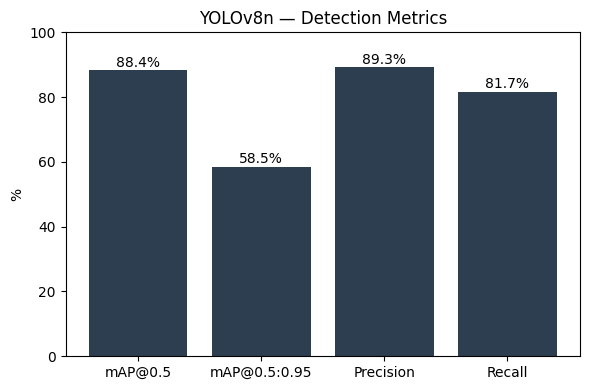

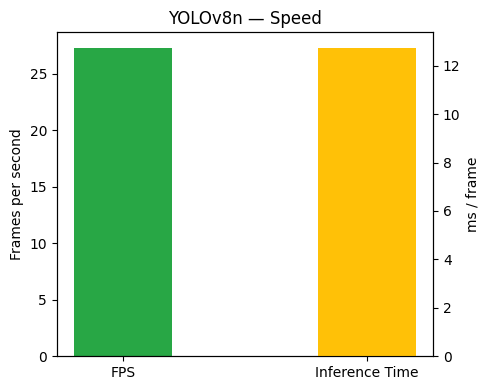

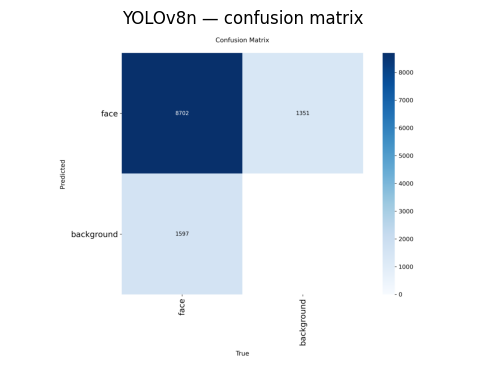

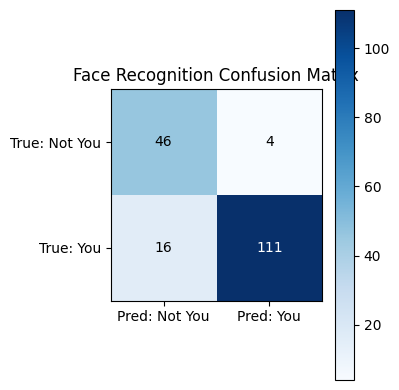

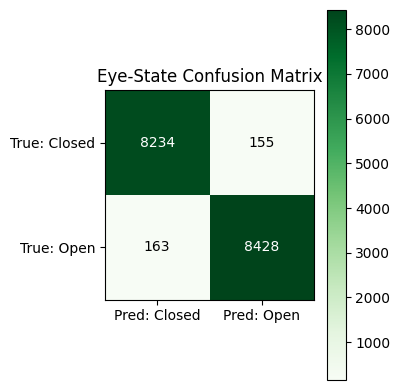

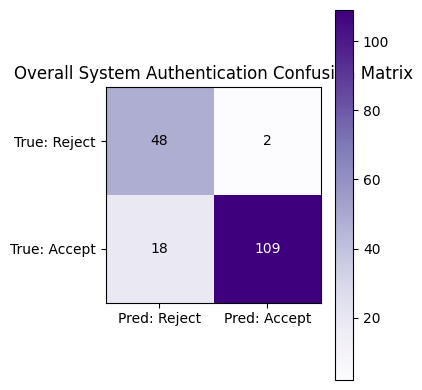

Overall System Accuracy = 88.70%
FAR = 4.00%
FRR = 14.17%
\n✅ Done. Copy the 'YOLOv8n' table values above into your HTML checklist.


In [30]:
# ================= FINAL RESULTS + GRAPHS FOR THE CURRENTLY LOADED YOLO MODEL =================
# Run this cell LAST, after running the YOLO / Face / Eye-State evaluation cells above
# for whichever YOLO model is currently loaded (v8n, v8-face, FaceV2, etc).
# Change CURRENT_YOLO_MODEL_NAME each time you swap models, then re-run cells 25-29.

CURRENT_YOLO_MODEL_NAME = "YOLOv8n"  # <-- change this to "YOLOv8-Face" / "YOLO-FaceV2" etc. each run

import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    %pip install pandas
    import pandas as pd
from IPython.display import display

def fmt(val, unit="%", scale=100, decimals=2):
    if val is None:
        return "Not run yet"
    if isinstance(val, str):
        return val
    return f"{val*scale:.{decimals}f}{unit}" if unit == "%" else f"{val:.{decimals}f} {unit}"

# ---------------------------------------------------------------
# 1) FULL RESULTS TABLE FOR THE CURRENT MODEL
# ---------------------------------------------------------------
rows = [
    ("Model", CURRENT_YOLO_MODEL_NAME),
    ("YOLO mAP@0.5",       fmt(yolo_map50)),
    ("YOLO mAP@0.5:0.95",  fmt(yolo_map)),
    ("YOLO Precision",     fmt(yolo_precision)),
    ("YOLO Recall",        fmt(yolo_recall)),
    ("YOLO FPS",           f"{yolo_fps:.1f}" if 'yolo_fps' in globals() and yolo_fps is not None else "Not run yet"),
    ("YOLO Inference Time",f"{yolo_avg_inf_ms:.1f} ms/frame" if 'yolo_avg_inf_ms' in globals() and yolo_avg_inf_ms is not None else "Not run yet"),
    ("YOLO Model Size",    f"{yolo_model_size_mb:.2f} MB" if 'yolo_model_size_mb' in globals() and yolo_model_size_mb is not None else "Not run yet"),
]
print(f"===== Results for {CURRENT_YOLO_MODEL_NAME} =====")
display(pd.DataFrame(rows, columns=["Metric", "Value"]))

# ---------------------------------------------------------------
# 2) BAR CHART: mAP@0.5 / mAP@0.5:0.95 / Precision / Recall
# ---------------------------------------------------------------
metric_labels = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]
metric_values = [yolo_map50, yolo_map, yolo_precision, yolo_recall]

if all(v is not None for v in metric_values):
    plt.figure(figsize=(6, 4))
    bars = plt.bar(metric_labels, [v * 100 for v in metric_values], color="#2c3e50")
    plt.ylim(0, 100)
    plt.ylabel("%")
    plt.title(f"{CURRENT_YOLO_MODEL_NAME} — Detection Metrics")
    for b, v in zip(bars, metric_values):
        plt.text(b.get_x() + b.get_width()/2, v*100 + 1, f"{v*100:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ YOLO metrics not fully available — run the YOLO mAP/Precision/Recall cell first.")

# ---------------------------------------------------------------
# 3) SPEED CHART: FPS + Inference Time
# ---------------------------------------------------------------
if 'yolo_fps' in globals() and yolo_fps is not None and 'yolo_avg_inf_ms' in globals() and yolo_avg_inf_ms is not None:
    fig, ax1 = plt.subplots(figsize=(5, 4))
    ax1.bar(["FPS"], [yolo_fps], color="#28a745", width=0.4)
    ax1.set_ylabel("Frames per second")
    ax2 = ax1.twinx()
    ax2.bar(["Inference Time"], [yolo_avg_inf_ms], color="#ffc107", width=0.4)
    ax2.set_ylabel("ms / frame")
    plt.title(f"{CURRENT_YOLO_MODEL_NAME} — Speed")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ FPS/Inference time not available — run the YOLO speed cell first.")

# ---------------------------------------------------------------
# 4) ULTRALYTICS AUTO-GENERATED PLOTS (confusion matrix, PR curve)
#    Saved automatically by yolo_model.val(..., plots=True) in cell 26.
# ---------------------------------------------------------------
if 'YOLO_VAL_SAVE_DIR' in globals() and YOLO_VAL_SAVE_DIR and os.path.isdir(YOLO_VAL_SAVE_DIR):
    for fname in ["confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
        fpath = os.path.join(YOLO_VAL_SAVE_DIR, fname)
        if os.path.exists(fpath):
            img = plt.imread(fpath)
            plt.figure(figsize=(6, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{CURRENT_YOLO_MODEL_NAME} — {fname.replace('_', ' ').replace('.png','')}")
            plt.show()
else:
    print("⚠️ No saved YOLO plots found — make sure cell 26 ran with plots=True.")

# ---------------------------------------------------------------
# 5) FACE RECOGNITION CONFUSION MATRIX (from cell 23, if it ran)
# ---------------------------------------------------------------
if all(v in globals() for v in ["tn", "fp", "fn", "tp"]):
    face_cm = np.array([[tn, fp], [fn, tp]])
    plt.figure(figsize=(4, 4))
    plt.imshow(face_cm, cmap="Blues")
    plt.title("Face Recognition Confusion Matrix")
    plt.xticks([0, 1], ["Pred: Not You", "Pred: You"])
    plt.yticks([0, 1], ["True: Not You", "True: You"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(face_cm[i, j]), ha="center", va="center",
                      color="white" if face_cm[i, j] > face_cm.max()/2 else "black")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Face recognition confusion-matrix values not found — run the Face Recognition cell first.")

# ---------------------------------------------------------------
# 6) EYE-STATE CONFUSION MATRIX (from cell 24, if it ran)
# ---------------------------------------------------------------
if all(v in globals() for v in ["eye_y_true", "eye_y_pred"]):
    eye_cm = confusion_matrix(eye_y_true, eye_y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 4))
    plt.imshow(eye_cm, cmap="Greens")
    plt.title("Eye-State Confusion Matrix")
    plt.xticks([0, 1], ["Pred: Closed", "Pred: Open"])
    plt.yticks([0, 1], ["True: Closed", "True: Open"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(eye_cm[i, j]), ha="center", va="center",
                      color="white" if eye_cm[i, j] > eye_cm.max()/2 else "black")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Eye-State confusion-matrix values not found — run the Eye-State cell first.")

# ---------------------------------------------------------------
# 7) OVERALL SYSTEM CONFUSION MATRIX (from the Overall System cell, if it ran)
# ---------------------------------------------------------------
if all(v in globals() for v in ["overall_tp", "overall_tn", "overall_fp", "overall_fn"]) and overall_tp is not None:
    overall_cm = np.array([[overall_tn, overall_fp], [overall_fn, overall_tp]])
    plt.figure(figsize=(4, 4))
    plt.imshow(overall_cm, cmap="Purples")
    plt.title("Overall System Authentication Confusion Matrix")
    plt.xticks([0, 1], ["Pred: Reject", "Pred: Accept"])
    plt.yticks([0, 1], ["True: Reject", "True: Accept"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(overall_cm[i, j]), ha="center", va="center",
                      color="white" if overall_cm[i, j] > overall_cm.max()/2 else "black")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    print(f"Overall System Accuracy = {overall_accuracy*100:.2f}%")
    print(f"FAR = {overall_FAR*100:.2f}%" if overall_FAR is not None else "FAR = N/A")
    print(f"FRR = {overall_FRR*100:.2f}%" if overall_FRR is not None else "FRR = N/A")
else:
    print("[!] Overall System confusion-matrix values not found - run the Overall System Authentication Performance cell first.")

print(f"\\n✅ Done. Copy the '{CURRENT_YOLO_MODEL_NAME}' table values above into your HTML checklist.")


In [31]:
# ================================================================
# FINAL OVERALL SYSTEM PERFORMANCE
# FACE + EYE-STATE ONLY
# Fingerprint is NOT included here.
# ================================================================

import random
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# ------------------------------------------------
# Reset previous values
# ------------------------------------------------
overall_tp = None
overall_tn = None
overall_fp = None
overall_fn = None

overall_accuracy = None
overall_FAR = None
overall_FRR = None

# ------------------------------------------------
# Check required Face + Eye results
# ------------------------------------------------
required_vars = [
    "y_true",
    "y_pred",
    "eye_y_true",
    "eye_y_pred"
]

missing_vars = [
    v for v in required_vars
    if v not in globals() or len(globals()[v]) == 0
]

if missing_vars:

    print("⚠️ Missing required results:")
    print(missing_vars)

    print("\nPlease run:")
    print("1. Face Recognition evaluation cell")
    print("2. Eye-State / EyeCNN evaluation cell")

else:

    # ============================================================
    # FACE DATA
    # ============================================================

    face_pairs = list(zip(y_true, y_pred))

    # Genuine user = 1
    # Impostor = 0

    genuine_faces = [
        (true, pred)
        for true, pred in face_pairs
        if true == 1
    ]

    impostor_faces = [
        (true, pred)
        for true, pred in face_pairs
        if true == 0
    ]

    # ============================================================
    # EYE DATA
    # ============================================================

    eye_pairs = list(zip(eye_y_true, eye_y_pred))

    # Eye labels:
    # 1 = Awake / Open
    # 0 = Sleepy / Closed

    awake_eye_pairs = [
        (true, pred)
        for true, pred in eye_pairs
        if true == 1
    ]

    sleepy_eye_pairs = [
        (true, pred)
        for true, pred in eye_pairs
        if true == 0
    ]

    # ============================================================
    # CHECK DATA
    # ============================================================

    if not genuine_faces:
        print("⚠️ No genuine face samples found.")

    elif not impostor_faces:
        print("⚠️ No impostor face samples found.")

    elif not awake_eye_pairs:
        print("⚠️ No AWAKE eye samples found.")

    elif not sleepy_eye_pairs:
        print("⚠️ No SLEEPY eye samples found.")

    else:

        random.seed(42)

        # ========================================================
        # CREATE FINAL SYSTEM TRIALS
        # ========================================================

        system_true = []
        system_pred = []

        # --------------------------------------------------------
        # 1. GENUINE + AWAKE
        #
        # Correct answer = ACCEPT
        #
        # Face must say "You"
        # AND
        # Eye must say "Awake"
        # --------------------------------------------------------

        for face_true, face_pred in genuine_faces:

            eye_true, eye_pred = random.choice(awake_eye_pairs)

            # Ground truth:
            # Genuine person + Awake = ACCEPT
            true_result = 1

            # System decision:
            # Accept only if face AND eye both pass
            predicted_result = int(
                face_pred == 1 and
                eye_pred == 1
            )

            system_true.append(true_result)
            system_pred.append(predicted_result)

        # --------------------------------------------------------
        # 2. GENUINE + SLEEPY/CLOSED
        #
        # Correct answer = REJECT
        #
        # This is the IMPORTANT PART of your research.
        #
        # Even though the face belongs to the genuine user,
        # the system must reject because the user is not awake.
        # --------------------------------------------------------

        for face_true, face_pred in genuine_faces:

            eye_true, eye_pred = random.choice(sleepy_eye_pairs)

            # Ground truth:
            # Genuine person but sleepy = REJECT
            true_result = 0

            # System accepts only if:
            # Face = genuine AND Eye = awake
            predicted_result = int(
                face_pred == 1 and
                eye_pred == 1
            )

            system_true.append(true_result)
            system_pred.append(predicted_result)

        # --------------------------------------------------------
        # 3. IMPOSTOR + AWAKE
        #
        # Correct answer = REJECT
        # --------------------------------------------------------

        for face_true, face_pred in impostor_faces:

            eye_true, eye_pred = random.choice(awake_eye_pairs)

            # Impostor must be rejected
            true_result = 0

            predicted_result = int(
                face_pred == 1 and
                eye_pred == 1
            )

            system_true.append(true_result)
            system_pred.append(predicted_result)

        # --------------------------------------------------------
        # 4. IMPOSTOR + SLEEPY/CLOSED
        #
        # Correct answer = REJECT
        # --------------------------------------------------------

        for face_true, face_pred in impostor_faces:

            eye_true, eye_pred = random.choice(sleepy_eye_pairs)

            # Impostor must be rejected
            true_result = 0

            predicted_result = int(
                face_pred == 1 and
                eye_pred == 1
            )

            system_true.append(true_result)
            system_pred.append(predicted_result)

        # ========================================================
        # CONFUSION MATRIX
        # ========================================================

        overall_tn, overall_fp, overall_fn, overall_tp = confusion_matrix(
            system_true,
            system_pred,
            labels=[0, 1]
        ).ravel()

        # ========================================================
        # METRICS
        # ========================================================

        total_trials = (
            overall_tp +
            overall_tn +
            overall_fp +
            overall_fn
        )

        # Accuracy
        overall_accuracy = (
            (overall_tp + overall_tn) / total_trials
            if total_trials > 0
            else None
        )

        # False Acceptance Rate
        overall_FAR = (
            overall_fp / (overall_fp + overall_tn)
            if (overall_fp + overall_tn) > 0
            else None
        )

        # False Rejection Rate
        overall_FRR = (
            overall_fn / (overall_fn + overall_tp)
            if (overall_fn + overall_tp) > 0
            else None
        )

        # ========================================================
        # PRINT RESULTS
        # ========================================================

        print("=" * 65)
        print("     OVERALL SYSTEM AUTHENTICATION PERFORMANCE")
        print("             FACE + EYE-STATE ONLY")
        print("=" * 65)

        print("\nTrial composition:")
        print(f"Genuine + Awake          : {len(genuine_faces)}")
        print(f"Genuine + Sleepy/Closed  : {len(genuine_faces)}")
        print(f"Impostor + Awake         : {len(impostor_faces)}")
        print(f"Impostor + Sleepy/Closed : {len(impostor_faces)}")

        print(f"\nTotal Trials             : {total_trials}")

        print("\n----- Confusion Matrix -----")

        print(f"TP (Genuine + Awake accepted)  : {overall_tp}")
        print(f"TN (Incorrect users rejected)  : {overall_tn}")
        print(f"FP (Impostor accepted)         : {overall_fp}")
        print(f"FN (Valid attempt rejected)   : {overall_fn}")

        print("\n----- Overall System Metrics -----")

        print(
            f"Overall System Accuracy : "
            f"{overall_accuracy * 100:.2f}%"
        )

        print(
            f"Overall System FAR      : "
            f"{overall_FAR * 100:.2f}%"
        )

        print(
            f"Overall System FRR      : "
            f"{overall_FRR * 100:.2f}%"
        )

        print("=" * 65)

        # ========================================================
        # RESULTS TABLE
        # ========================================================

        overall_rows = [
            ("Overall System Accuracy", f"{overall_accuracy * 100:.2f}%"),
            ("Overall System FAR", f"{overall_FAR * 100:.2f}%"),
            ("Overall System FRR", f"{overall_FRR * 100:.2f}%"),
            ("True Positive (TP)", overall_tp),
            ("True Negative (TN)", overall_tn),
            ("False Positive (FP)", overall_fp),
            ("False Negative (FN)", overall_fn),
            ("Total Trials", total_trials),
        ]

        print("\n===== FINAL OVERALL RESULTS =====")

        display(
            pd.DataFrame(
                overall_rows,
                columns=["Metric", "Value"]
            )
        )

     OVERALL SYSTEM AUTHENTICATION PERFORMANCE
             FACE + EYE-STATE ONLY

Trial composition:
Genuine + Awake          : 127
Genuine + Sleepy/Closed  : 127
Impostor + Awake         : 50
Impostor + Sleepy/Closed : 50

Total Trials             : 354

----- Confusion Matrix -----
TP (Genuine + Awake accepted)  : 109
TN (Incorrect users rejected)  : 220
FP (Impostor accepted)         : 7
FN (Valid attempt rejected)   : 18

----- Overall System Metrics -----
Overall System Accuracy : 92.94%
Overall System FAR      : 3.08%
Overall System FRR      : 14.17%

===== FINAL OVERALL RESULTS =====


,Metric,Value
0,Overall System Accuracy,92.94%
1,Overall System FAR,3.08%
2,Overall System FRR,14.17%
3,True Positive (TP),109
4,True Negative (TN),220
5,False Positive (FP),7
6,False Negative (FN),18
7,Total Trials,354


FINAL RESULTS OUTPUT DIRECTORY
C:\Users\SERVER02\thesis\runs\detect\val


RESULTS FOR YOLOv8n


,Metric,Value
0,Model,YOLOv8n
1,YOLO mAP@0.5,88.37%
2,YOLO mAP@0.5:0.95,58.55%
3,YOLO Precision,89.31%
4,YOLO Recall,81.72%
5,YOLO FPS,27.3
6,YOLO Inference Time,12.7 ms/frame
7,YOLO Model Size,5.94 MB


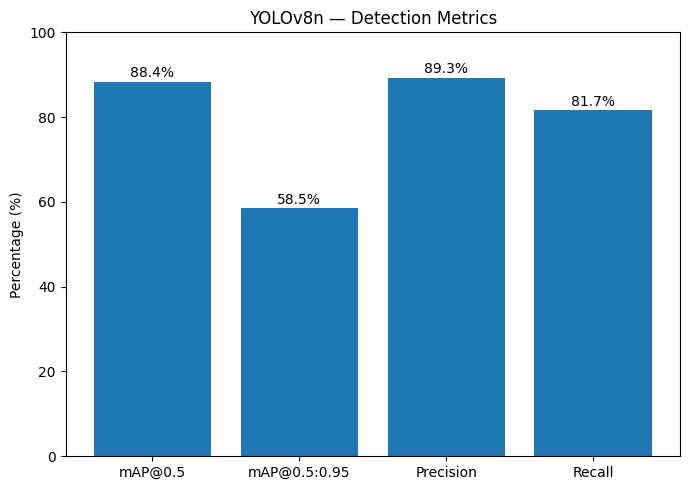

✅ Saved: C:\Users\SERVER02\thesis\runs\detect\val\YOLO_detection_metrics.png


C:\Users\SERVER02\thesis\runs\detect\val\YOLO_detection_metrics.png

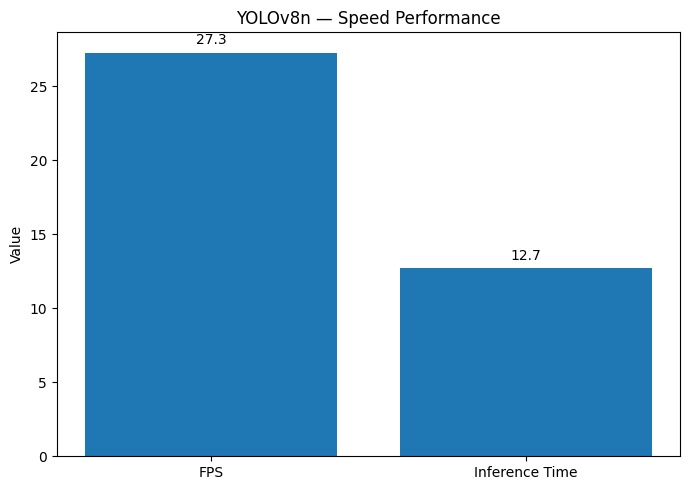

✅ Saved: C:\Users\SERVER02\thesis\runs\detect\val\YOLO_speed_performance.png


C:\Users\SERVER02\thesis\runs\detect\val\YOLO_speed_performance.png



YOLO VALIDATION PLOTS

📊 confusion_matrix.png
YOLOv8n — confusion_matrix.png


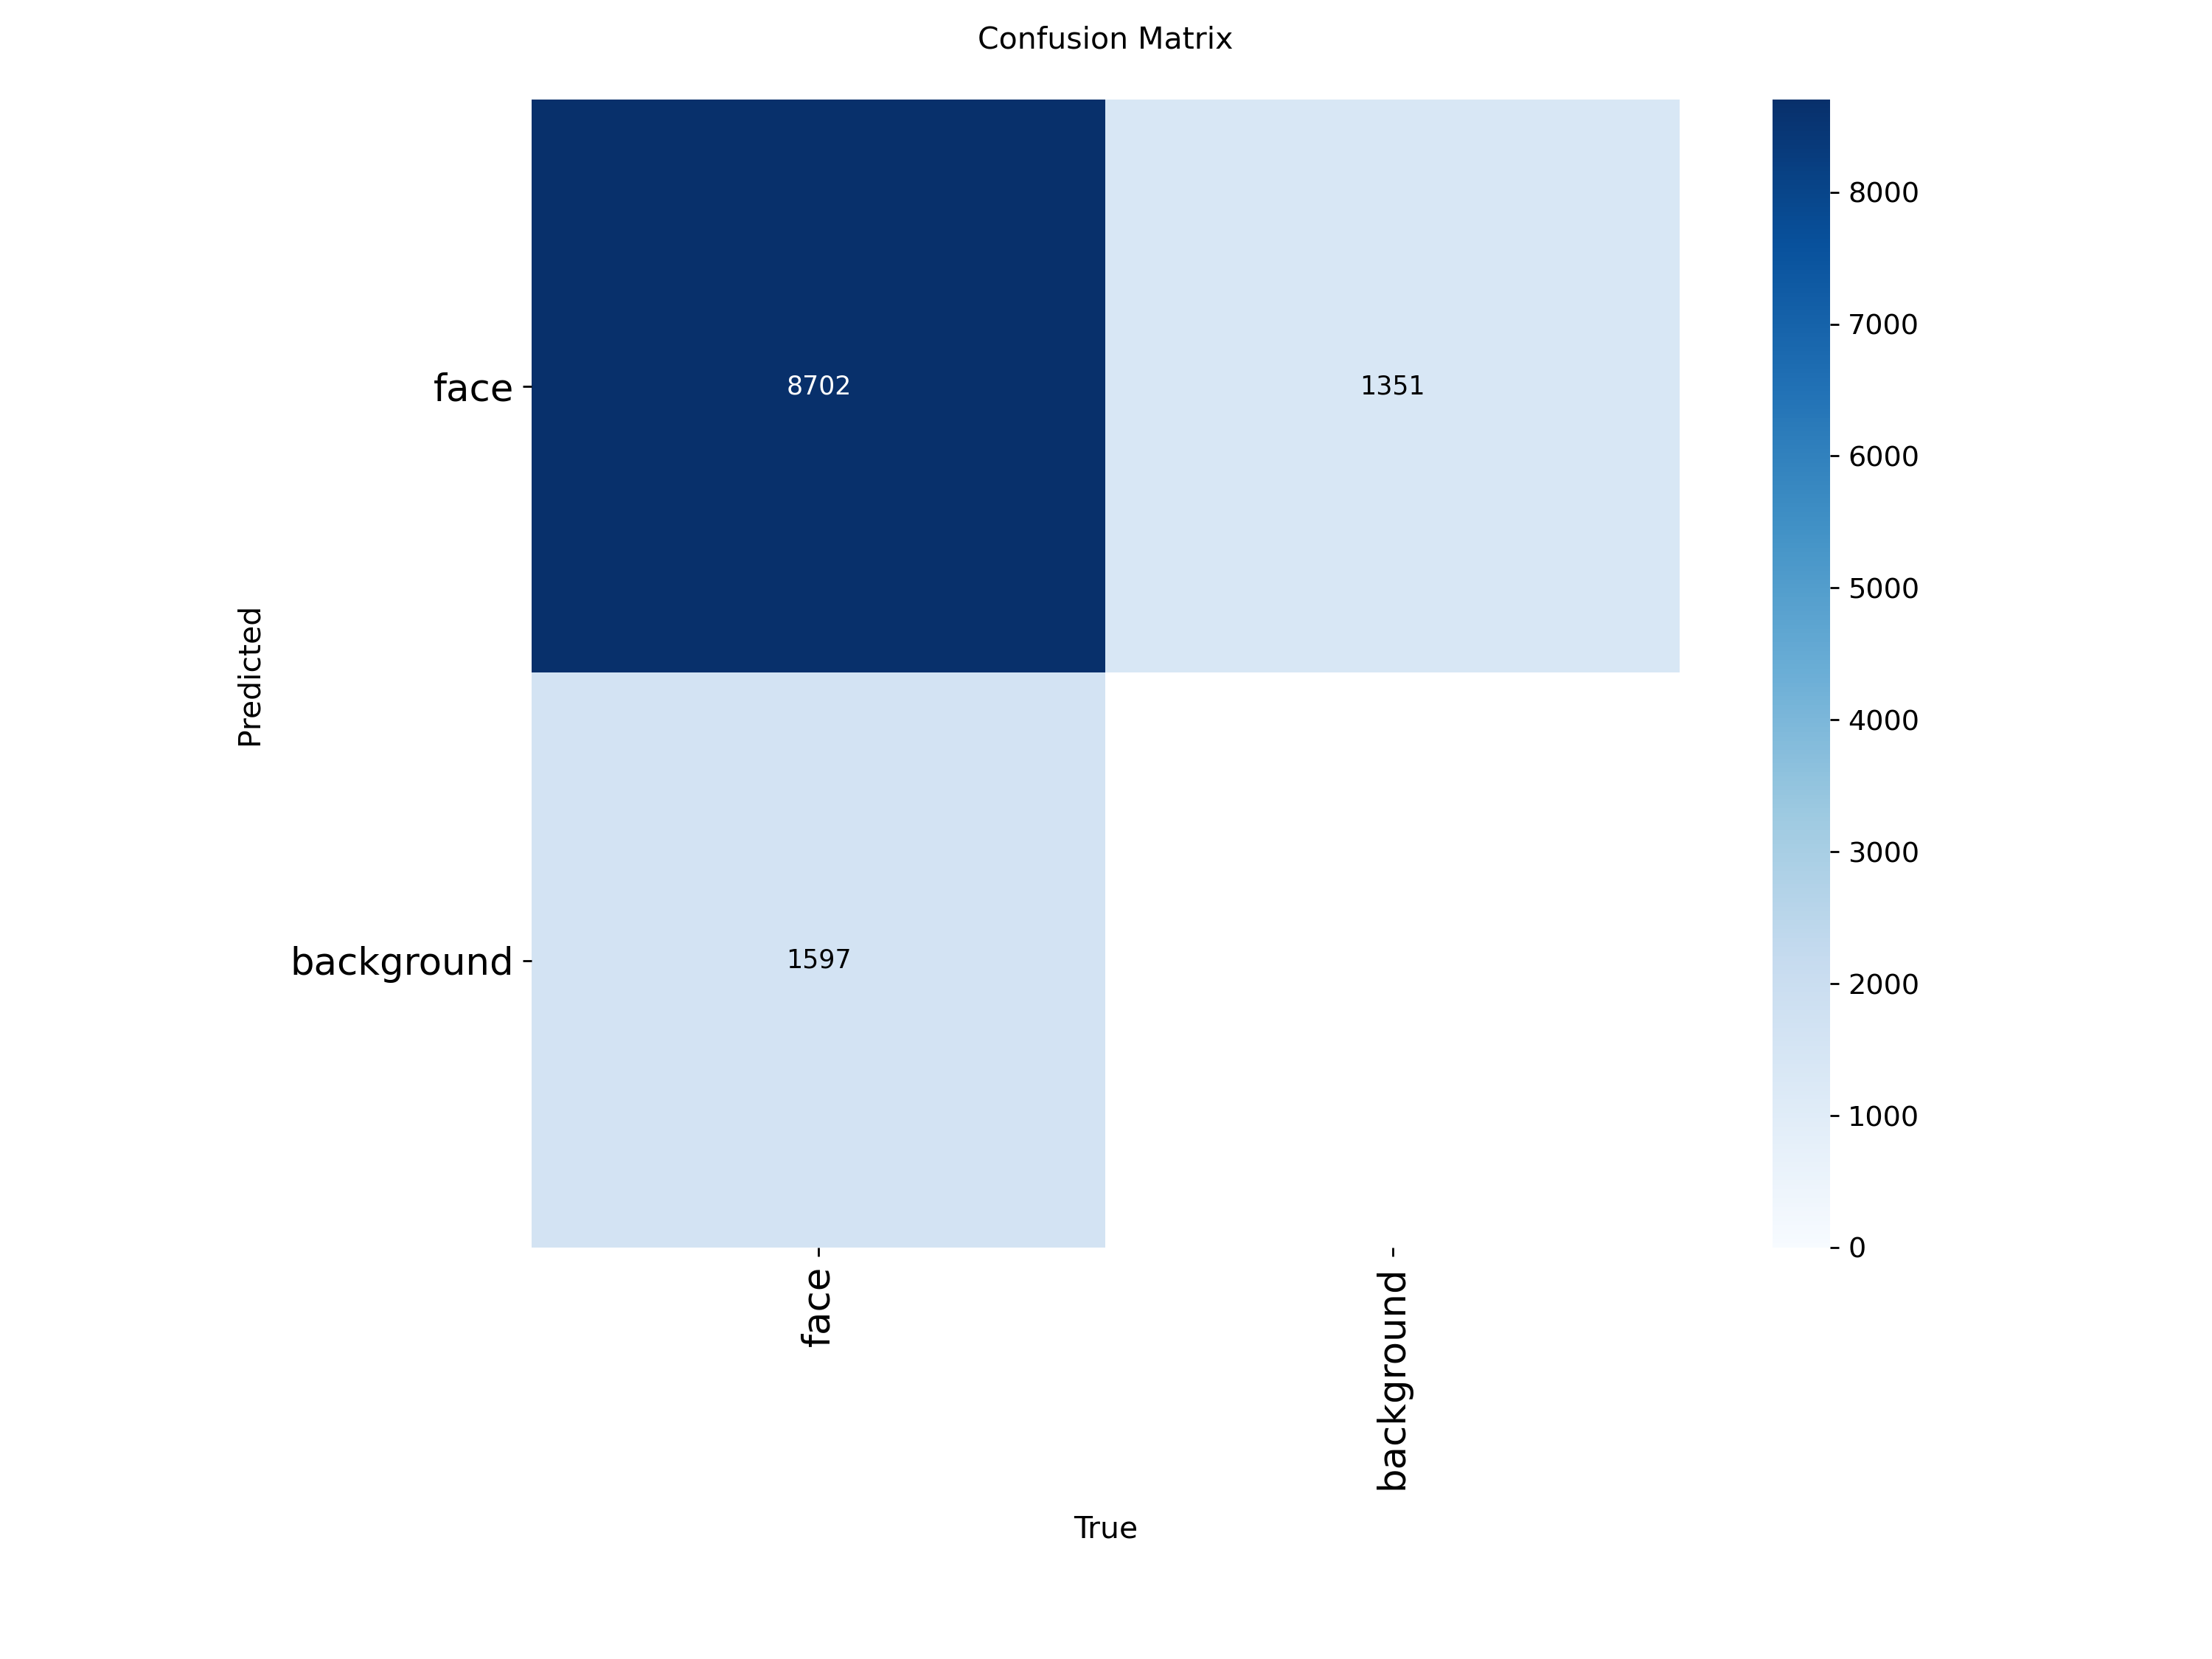

C:\Users\SERVER02\thesis\runs\detect\val\confusion_matrix.png

⚠️ Could not find YOLO plot: PR_curve.png
⚠️ Could not find YOLO plot: F1_curve.png


FACE RECOGNITION CONFUSION MATRIX


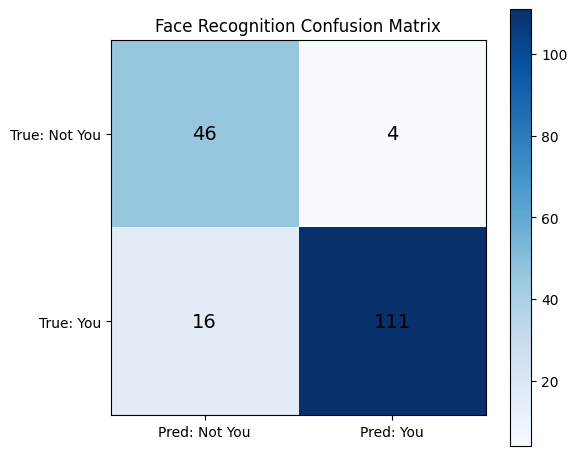

✅ Saved: C:\Users\SERVER02\thesis\runs\detect\val\face_recognition_confusion_matrix.png


C:\Users\SERVER02\thesis\runs\detect\val\face_recognition_confusion_matrix.png



EYE-STATE CONFUSION MATRIX


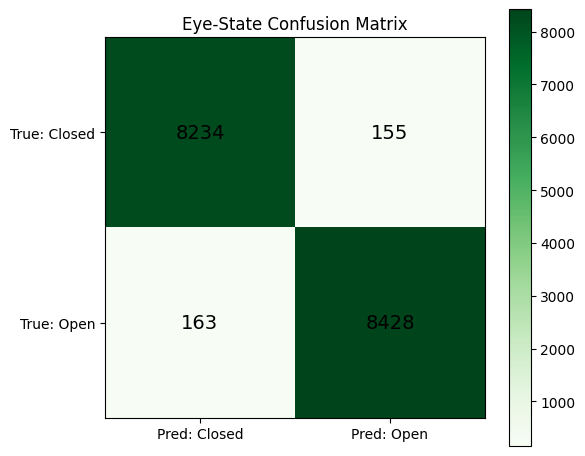

✅ Saved: C:\Users\SERVER02\thesis\runs\detect\val\eye_state_confusion_matrix.png


C:\Users\SERVER02\thesis\runs\detect\val\eye_state_confusion_matrix.png



OVERALL SYSTEM CONFUSION MATRIX
FACE + EYE-STATE ONLY


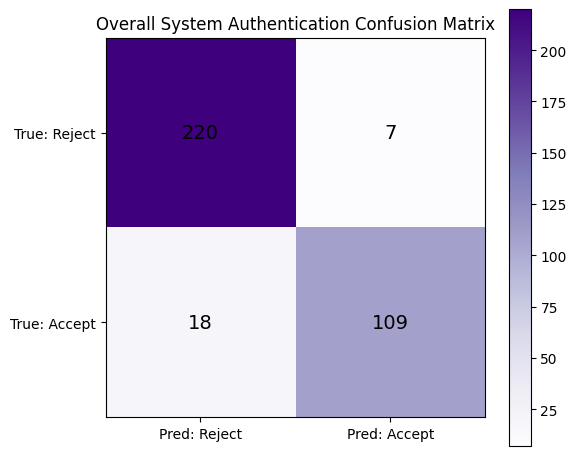

Overall System Accuracy = 92.94%
Overall System FAR = 3.08%
Overall System FRR = 14.17%
✅ Saved: C:\Users\SERVER02\thesis\runs\detect\val\overall_system_confusion_matrix.png


C:\Users\SERVER02\thesis\runs\detect\val\overall_system_confusion_matrix.png



ALL SAVED RESULTS
✅ C:\Users\SERVER02\thesis\runs\detect\val\BoxF1_curve.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\BoxPR_curve.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\BoxP_curve.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\BoxR_curve.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\YOLO_detection_metrics.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\YOLO_speed_performance.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\confusion_matrix.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\confusion_matrix_normalized.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\eye_state_confusion_matrix.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\face_recognition_confusion_matrix.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\overall_system_confusion_matrix.png
✅ C:\Users\SERVER02\thesis\runs\detect\val\val_batch0_labels.jpg
✅ C:\Users\SERVER02\thesis\runs\detect\val\val_batch0_pred.jpg
✅ C:\Users\SERVER02\thesis\runs\detect\val\val_batch1_labels.jpg
✅ C:\Users\SERVER02\thesis\runs\detect\v

In [32]:
# ================================================================
# FINAL RESULTS + GRAPHS FOR CURRENTLY LOADED YOLO MODEL
# ================================================================
# This cell:
#   1. Shows YOLO metrics
#   2. Shows YOLO plots correctly
#   3. Saves all graphs/images to runs/detect/val
#   4. Shows Face confusion matrix
#   5. Shows Eye-State confusion matrix
#   6. Shows Overall System confusion matrix
#   7. Provides download links for all generated images
# ================================================================

CURRENT_YOLO_MODEL_NAME = "YOLOv8n"

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display, Image, FileLink
from sklearn.metrics import confusion_matrix


# ================================================================
# 0) CREATE FINAL OUTPUT DIRECTORY
# ================================================================

FINAL_SAVE_DIR = os.path.abspath(
    os.path.join("runs", "detect", "val")
)

os.makedirs(FINAL_SAVE_DIR, exist_ok=True)

print("=" * 70)
print("FINAL RESULTS OUTPUT DIRECTORY")
print("=" * 70)
print(FINAL_SAVE_DIR)


# ================================================================
# HELPER FUNCTION: DISPLAY + SAVE IMAGE
# ================================================================

def show_saved_image(filepath, title=None, width=700):

    if not os.path.exists(filepath):
        print(f"⚠️ Image not found: {filepath}")
        return

    print(f"\n📊 {os.path.basename(filepath)}")

    if title:
        print(title)

    # Display the actual PNG file directly.
    # This avoids the broken/incorrect rendering caused by
    # loading the image into another matplotlib figure.
    display(Image(
        filename=filepath,
        width=width
    ))

    # Download link
    display(FileLink(
        filepath,
        result_html_prefix="⬇️ Download: "
    ))


# ================================================================
# HELPER FUNCTION: COPY YOLO GENERATED PLOTS
# ================================================================

def copy_yolo_plot(filename):

    destination = os.path.join(
        FINAL_SAVE_DIR,
        filename
    )

    # Possible source locations
    possible_sources = []

    # Your YOLO validation save directory
    if (
        "YOLO_VAL_SAVE_DIR" in globals()
        and YOLO_VAL_SAVE_DIR
        and os.path.isdir(YOLO_VAL_SAVE_DIR)
    ):
        possible_sources.append(
            os.path.join(YOLO_VAL_SAVE_DIR, filename)
        )

    # Standard Ultralytics location
    possible_sources.append(
        os.path.abspath(
            os.path.join("runs", "detect", "val", filename)
        )
    )

    # Search for first existing source
    source = None

    for src in possible_sources:

        if os.path.exists(src):

            source = os.path.abspath(src)
            break

    if source is None:

        print(f"⚠️ Could not find YOLO plot: {filename}")
        return None

    # Don't copy file onto itself
    if os.path.abspath(source) != os.path.abspath(destination):

        shutil.copy2(
            source,
            destination
        )

    return destination


# ================================================================
# 1) YOLO RESULTS TABLE
# ================================================================

def fmt(val, unit="%", scale=100, decimals=2):

    if val is None:
        return "Not run yet"

    if isinstance(val, str):
        return val

    if unit == "%":
        return f"{val * scale:.{decimals}f}%"

    return f"{val:.{decimals}f} {unit}"


rows = [
    ("Model", CURRENT_YOLO_MODEL_NAME),

    (
        "YOLO mAP@0.5",
        fmt(yolo_map50)
        if "yolo_map50" in globals()
        else "Not run yet"
    ),

    (
        "YOLO mAP@0.5:0.95",
        fmt(yolo_map)
        if "yolo_map" in globals()
        else "Not run yet"
    ),

    (
        "YOLO Precision",
        fmt(yolo_precision)
        if "yolo_precision" in globals()
        else "Not run yet"
    ),

    (
        "YOLO Recall",
        fmt(yolo_recall)
        if "yolo_recall" in globals()
        else "Not run yet"
    ),

    (
        "YOLO FPS",
        f"{yolo_fps:.1f}"
        if "yolo_fps" in globals()
        and yolo_fps is not None
        else "Not run yet"
    ),

    (
        "YOLO Inference Time",
        f"{yolo_avg_inf_ms:.1f} ms/frame"
        if "yolo_avg_inf_ms" in globals()
        and yolo_avg_inf_ms is not None
        else "Not run yet"
    ),

    (
        "YOLO Model Size",
        f"{yolo_model_size_mb:.2f} MB"
        if "yolo_model_size_mb" in globals()
        and yolo_model_size_mb is not None
        else "Not run yet"
    ),
]


print("\n")
print("=" * 70)
print(f"RESULTS FOR {CURRENT_YOLO_MODEL_NAME}")
print("=" * 70)

display(
    pd.DataFrame(
        rows,
        columns=["Metric", "Value"]
    )
)


# ================================================================
# 2) YOLO DETECTION METRICS BAR CHART
# ================================================================

if all(
    v in globals()
    for v in [
        "yolo_map50",
        "yolo_map",
        "yolo_precision",
        "yolo_recall"
    ]
):

    metric_labels = [
        "mAP@0.5",
        "mAP@0.5:0.95",
        "Precision",
        "Recall"
    ]

    metric_values = [
        yolo_map50,
        yolo_map,
        yolo_precision,
        yolo_recall
    ]

    if all(v is not None for v in metric_values):

        fig = plt.figure(figsize=(7, 5))

        bars = plt.bar(
            metric_labels,
            [v * 100 for v in metric_values]
        )

        plt.ylim(0, 100)
        plt.ylabel("Percentage (%)")
        plt.title(
            f"{CURRENT_YOLO_MODEL_NAME} — Detection Metrics"
        )

        for bar, value in zip(
            bars,
            metric_values
        ):

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value * 100 + 1,
                f"{value * 100:.1f}%",
                ha="center"
            )

        plt.tight_layout()

        metric_chart_path = os.path.join(
            FINAL_SAVE_DIR,
            "YOLO_detection_metrics.png"
        )

        plt.savefig(
            metric_chart_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

        print(
            f"✅ Saved: {metric_chart_path}"
        )

        display(
            FileLink(
                metric_chart_path,
                result_html_prefix="⬇️ Download: "
            )
        )


# ================================================================
# 3) YOLO SPEED CHART
# ================================================================

if (
    "yolo_fps" in globals()
    and yolo_fps is not None
    and "yolo_avg_inf_ms" in globals()
    and yolo_avg_inf_ms is not None
):

    fig = plt.figure(figsize=(7, 5))

    x = ["FPS", "Inference Time"]

    # Separate values but displayed on a single readable chart
    bars = plt.bar(
        x,
        [yolo_fps, yolo_avg_inf_ms]
    )

    plt.ylabel("Value")
    plt.title(
        f"{CURRENT_YOLO_MODEL_NAME} — Speed Performance"
    )

    for bar, value in zip(
        bars,
        [yolo_fps, yolo_avg_inf_ms]
    ):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + max(yolo_fps, yolo_avg_inf_ms) * 0.02,
            f"{value:.1f}",
            ha="center"
        )

    plt.tight_layout()

    speed_chart_path = os.path.join(
        FINAL_SAVE_DIR,
        "YOLO_speed_performance.png"
    )

    plt.savefig(
        speed_chart_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"✅ Saved: {speed_chart_path}"
    )

    display(
        FileLink(
            speed_chart_path,
            result_html_prefix="⬇️ Download: "
        )
    )


# ================================================================
# 4) ULTRALYTICS YOLO GENERATED PLOTS
# ================================================================

print("\n")
print("=" * 70)
print("YOLO VALIDATION PLOTS")
print("=" * 70)

yolo_plot_files = [
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png"
]

for fname in yolo_plot_files:

    saved_path = copy_yolo_plot(fname)

    if saved_path:

        show_saved_image(
            saved_path,
            title=f"{CURRENT_YOLO_MODEL_NAME} — {fname}"
        )


# ================================================================
# 5) FACE RECOGNITION CONFUSION MATRIX
# ================================================================

print("\n")
print("=" * 70)
print("FACE RECOGNITION CONFUSION MATRIX")
print("=" * 70)

if all(
    v in globals()
    for v in ["tn", "fp", "fn", "tp"]
):

    face_cm = np.array([
        [tn, fp],
        [fn, tp]
    ])

    fig = plt.figure(figsize=(6, 5))

    plt.imshow(
        face_cm,
        cmap="Blues"
    )

    plt.title(
        "Face Recognition Confusion Matrix"
    )

    plt.xticks(
        [0, 1],
        ["Pred: Not You", "Pred: You"]
    )

    plt.yticks(
        [0, 1],
        ["True: Not You", "True: You"]
    )

    for i in range(2):

        for j in range(2):

            plt.text(
                j,
                i,
                str(face_cm[i, j]),
                ha="center",
                va="center",
                fontsize=14
            )

    plt.colorbar()
    plt.tight_layout()

    face_cm_path = os.path.join(
        FINAL_SAVE_DIR,
        "face_recognition_confusion_matrix.png"
    )

    plt.savefig(
        face_cm_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"✅ Saved: {face_cm_path}"
    )

    display(
        FileLink(
            face_cm_path,
            result_html_prefix="⬇️ Download: "
        )
    )

else:

    print(
        "⚠️ Face confusion-matrix values not found."
    )


# ================================================================
# 6) EYE-STATE CONFUSION MATRIX
# ================================================================

print("\n")
print("=" * 70)
print("EYE-STATE CONFUSION MATRIX")
print("=" * 70)

if all(
    v in globals()
    for v in [
        "eye_y_true",
        "eye_y_pred"
    ]
):

    eye_cm = confusion_matrix(
        eye_y_true,
        eye_y_pred,
        labels=[0, 1]
    )

    fig = plt.figure(figsize=(6, 5))

    plt.imshow(
        eye_cm,
        cmap="Greens"
    )

    plt.title(
        "Eye-State Confusion Matrix"
    )

    plt.xticks(
        [0, 1],
        ["Pred: Closed", "Pred: Open"]
    )

    plt.yticks(
        [0, 1],
        ["True: Closed", "True: Open"]
    )

    for i in range(2):

        for j in range(2):

            plt.text(
                j,
                i,
                str(eye_cm[i, j]),
                ha="center",
                va="center",
                fontsize=14
            )

    plt.colorbar()
    plt.tight_layout()

    eye_cm_path = os.path.join(
        FINAL_SAVE_DIR,
        "eye_state_confusion_matrix.png"
    )

    plt.savefig(
        eye_cm_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"✅ Saved: {eye_cm_path}"
    )

    display(
        FileLink(
            eye_cm_path,
            result_html_prefix="⬇️ Download: "
        )
    )

else:

    print(
        "⚠️ Eye-State values not found."
    )


# ================================================================
# 7) OVERALL SYSTEM CONFUSION MATRIX
# ================================================================

print("\n")
print("=" * 70)
print("OVERALL SYSTEM CONFUSION MATRIX")
print("FACE + EYE-STATE ONLY")
print("=" * 70)

if all(
    v in globals()
    for v in [
        "overall_tp",
        "overall_tn",
        "overall_fp",
        "overall_fn"
    ]
) and overall_tp is not None:

    overall_cm = np.array([
        [overall_tn, overall_fp],
        [overall_fn, overall_tp]
    ])

    fig = plt.figure(figsize=(6, 5))

    plt.imshow(
        overall_cm,
        cmap="Purples"
    )

    plt.title(
        "Overall System Authentication Confusion Matrix"
    )

    plt.xticks(
        [0, 1],
        ["Pred: Reject", "Pred: Accept"]
    )

    plt.yticks(
        [0, 1],
        ["True: Reject", "True: Accept"]
    )

    for i in range(2):

        for j in range(2):

            plt.text(
                j,
                i,
                str(overall_cm[i, j]),
                ha="center",
                va="center",
                fontsize=14
            )

    plt.colorbar()
    plt.tight_layout()

    overall_cm_path = os.path.join(
        FINAL_SAVE_DIR,
        "overall_system_confusion_matrix.png"
    )

    plt.savefig(
        overall_cm_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"Overall System Accuracy = "
        f"{overall_accuracy * 100:.2f}%"
    )

    print(
        f"Overall System FAR = "
        f"{overall_FAR * 100:.2f}%"
        if overall_FAR is not None
        else "Overall System FAR = N/A"
    )

    print(
        f"Overall System FRR = "
        f"{overall_FRR * 100:.2f}%"
        if overall_FRR is not None
        else "Overall System FRR = N/A"
    )

    print(
        f"✅ Saved: {overall_cm_path}"
    )

    display(
        FileLink(
            overall_cm_path,
            result_html_prefix="⬇️ Download: "
        )
    )

else:

    print(
        "⚠️ Overall System confusion-matrix values not found."
    )

    print(
        "Run your Overall System Authentication Performance cell first."
    )


# ================================================================
# 8) FINAL OUTPUT FILE LIST
# ================================================================

print("\n")
print("=" * 70)
print("ALL SAVED RESULTS")
print("=" * 70)

saved_files = sorted(
    [
        f
        for f in os.listdir(FINAL_SAVE_DIR)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]
)

if saved_files:

    for f in saved_files:

        print(
            "✅",
            os.path.join(
                FINAL_SAVE_DIR,
                f
            )
        )

else:

    print("⚠️ No image files found.")

print("\n")
print("=" * 70)
print("✅ FINAL RESULTS COMPLETED")
print("=" * 70)